# Proyecto

1. **Data Collect - Overview**
2. **Data Quality y Cleaning**
3. **Preparación para el EDA**
4. **EDA del dataset completo**
5. **Data Transformation: Producto P009**
6. **Insights: análisis del Producto P009**


## 1. Data Collect y overview inicial

En esta sección se visualiza la estructura inicial del dataset como primeras filas, información general y dimensiones.


In [57]:
import pandas as pd

df=pd.read_csv("demand_forecasting.csv")

In [58]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df.head()

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Promotion,Competitor Pricing,Seasonality,Epidemic,Demand
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,Snowy,0,85.73,Winter,0,115
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,Snowy,1,92.02,Winter,0,229
2,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,10,Snowy,1,60.08,Winter,0,157
3,2022-01-01,S001,P0004,Electronics,North,139,45,102,87.63,10,Snowy,0,85.19,Winter,0,52
4,2022-01-01,S001,P0005,Groceries,North,152,65,271,54.41,0,Snowy,0,51.63,Winter,0,59


In [59]:
# Muestra las primeras filas de df para revisar visualmente la data; puedes cambiar head() por head(10), y verás más filas.
df.head()


,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Promotion,Competitor Pricing,Seasonality,Epidemic,Demand
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,Snowy,0,85.73,Winter,0,115
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,Snowy,1,92.02,Winter,0,229
2,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,10,Snowy,1,60.08,Winter,0,157
3,2022-01-01,S001,P0004,Electronics,North,139,45,102,87.63,10,Snowy,0,85.19,Winter,0,52
4,2022-01-01,S001,P0005,Groceries,North,152,65,271,54.41,0,Snowy,0,51.63,Winter,0,59


In [ ]:
# Muestra columnas, tipos de datos y nulos de df; no cambia la data, solo ayuda a diagnosticar calidad y estructura.
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 76000 entries, 0 to 75999
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                76000 non-null  str    
 1   Store ID            76000 non-null  str    
 2   Product ID          76000 non-null  str    
 3   Category            76000 non-null  str    
 4   Region              76000 non-null  str    
 5   Inventory Level     76000 non-null  int64  
 6   Units Sold          76000 non-null  int64  
 7   Units Ordered       76000 non-null  int64  
 8   Price               76000 non-null  float64
 9   Discount            76000 non-null  int64  
 10  Weather Condition   76000 non-null  str    
 11  Promotion           76000 non-null  int64  
 12  Competitor Pricing  76000 non-null  float64
 13  Seasonality         76000 non-null  str    
 14  Epidemic            76000 non-null  int64  
 15  Demand              76000 non-null  int64  
dtypes: float64(2), 

In [ ]:
# Muestra filas y columnas de df; sirve para saber el tamaño del dataset, y no conviene modificarlo porque solo es consulta.
df.shape


(76000, 16)

## 2. Data Quality & Cleaning

Esta sección se enfoca únicamente en revisar y limpiar la calidad de los datos como tipos de datos, nombres de columnas, duplicados y nulos.


### 2.1 Revisión de tipos de datos y rango temporal

Se convierte la columna de fecha y se revisan los tipos de variables disponibles.


In [ ]:
# Convierte una columna de fecha a formato datetime para poder extraer año, mes o graficar en el tiempo; cambia el nombre de columna solo si existe.
df['Date'] = pd.to_datetime(df['Date'])


In [ ]:
# Obtiene el valor máximo para identificar o ajustar referencias; cambia la columna solo si quieres otro criterio.
print(f"Desde: {df['Date'].min()}  Hasta: {df['Date'].max()}")


Desde: 2022-01-01 00:00:00  Hasta: 2024-01-30 00:00:00


In [ ]:
# Muestra los tipos de datos de df; sirve para detectar columnas numéricas, fechas y categóricas antes de graficar o limpiar.
df.dtypes

Date                  datetime64[us]
Store ID                         str
Product ID                       str
Category                         str
Region                           str
Inventory Level                int64
Units Sold                     int64
Units Ordered                  int64
Price                        float64
Discount                       int64
Weather Condition                str
Promotion                      int64
Competitor Pricing           float64
Seasonality                      str
Epidemic                       int64
Demand                         int64
dtype: object

### 2.2 Revisión de valores únicos, duplicados y nulos

Se revisan valores únicos, registros duplicados y presencia de datos faltantes.


In [ ]:
# Cuenta valores únicos por columna para entender variedad de categorías o códigos; puedes cambiar ascending para ordenar al revés.
df.nunique().sort_values(ascending=True)

Epidemic                  2
Promotion                 2
Region                    4
Seasonality               4
Weather Condition         4
Store ID                  5
Category                  5
Discount                  6
Product ID               20
Units Sold              330
Demand                  340
Date                    760
Units Ordered           996
Inventory Level        1426
Price                 15396
Competitor Pricing    15963
dtype: int64

In [ ]:
# Cuenta filas duplicadas para evaluar limpieza de datos; no cambia nada, solo indica si hay registros repetidos.
df.duplicated().sum()

np.int64(0)

In [ ]:
# Muestra nulos en las primeras filas para revisar valores faltantes; puedes cambiar head(10) para ver más o menos filas.
df.isnull().head(10)

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Promotion,Competitor Pricing,Seasonality,Epidemic,Demand
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
5,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
6,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
7,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
8,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
9,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [ ]:
# Cuenta nulos por fila para detectar registros con muchos vacíos; puedes cambiar head(10), pero no recomiendo cambiar axis=1 si quieres revisar filas.
df.isnull().sum(axis=1).sort_values(ascending=False).head(10)

0    0
1    0
2    0
3    0
4    0
5    0
6    0
7    0
8    0
9    0
dtype: int64

### 2.3 Limpieza de nombres, tipos y duplicados

Se estandarizan nombres de columnas, se ajustan tipos categóricos y se eliminan duplicados.


In [ ]:
# Crea un diccionario para traducir nombres originales de columnas a nombres más simples
renombrar = {
            # Renombra la columna original 'Date' como 'date'; puedes cambiar el nombre final, pero luego debes actualizar todo el código que lo use.
            "Date":"date",
             # Renombra la columna original 'Store ID' como 'store_id'; puedes cambiar el nombre final, pero luego debes actualizar todo el código que lo use.
             "Store ID":"store_id",
             # Renombra la columna original 'Product ID' como 'product_id'; puedes cambiar el nombre final, pero luego debes actualizar todo el código que lo use.
             "Product ID" : "product_id",
             # Renombra la columna original 'Category' como 'category'; puedes cambiar el nombre final, pero luego debes actualizar todo el código que lo use.
             "Category":"category",
             # Renombra la columna original 'Region' como 'region'; puedes cambiar el nombre final, pero luego debes actualizar todo el código que lo use.
             "Region": "region",
             # Renombra la columna original 'Inventory Level' como 'inventory_level'; puedes cambiar el nombre final, pero luego debes actualizar todo el código que lo use.
             "Inventory Level": "inventory_level",
             # Renombra la columna original 'Units Sold' como 'units_sold'; puedes cambiar el nombre final, pero luego debes actualizar todo el código que lo use.
             "Units Sold": "units_sold",
             # Renombra la columna original 'Units Ordered' como 'units_ordered'; puedes cambiar el nombre final, pero luego debes actualizar todo el código que lo use.
             "Units Ordered": "units_ordered",
             # Renombra la columna original 'Price' como 'price'; puedes cambiar el nombre final, pero luego debes actualizar todo el código que lo use.
             "Price": "price",
             # Renombra la columna original 'Discount' como 'discount'; puedes cambiar el nombre final, pero luego debes actualizar todo el código que lo use.
             "Discount": "discount",
             # Renombra la columna original 'Weather Condition' como 'weather_condition'; puedes cambiar el nombre final, pero luego debes actualizar todo el código que lo use.
             "Weather Condition": "weather_condition",
             # Renombra la columna original 'Promotion' como 'is_promotion'; puedes cambiar el nombre final, pero luego debes actualizar todo el código que lo use.
             "Promotion": "is_promotion",
             # Renombra la columna original 'Competitor Pricing' como 'competitor_pricing'; puedes cambiar el nombre final, pero luego debes actualizar todo el código que lo use.
             "Competitor Pricing": "competitor_pricing",
             # Renombra la columna original 'Seasonality' como 'seasonality'; puedes cambiar el nombre final, pero luego debes actualizar todo el código que lo use.
             "Seasonality": "seasonality",
              # Renombra la columna original 'Epidemic' como 'is_epidemic'; puedes cambiar el nombre final, pero luego debes actualizar todo el código que lo use.
              "Epidemic":  "is_epidemic",
             # Renombra la columna original 'Demand' como 'demand'; puedes cambiar el nombre final, pero luego debes actualizar todo el código que lo use.
             "Demand" : "demand"
}
# Aplica el renombrado de columnas al DataFrame
df.rename(columns=renombrar, inplace=True)
print(list(df.columns))

['date', 'store_id', 'product_id', 'category', 'region', 'inventory_level', 'units_sold', 'units_ordered', 'price', 'discount', 'weather_condition', 'is_promotion', 'competitor_pricing', 'seasonality', 'is_epidemic', 'demand']


In [ ]:
# Convierte is_promotion a tipo categoría para tratarla como variable cualitativa; cambia la columna solo si existe y es realmente categórica.
df["is_promotion"] = df["is_promotion"].astype('category')
# Convierte is_epidemic a tipo categoría para tratarla como variable cualitativa; cambia la columna solo si existe y es realmente categórica.
df["is_epidemic"] = df["is_epidemic"].astype('category')


In [ ]:
# Muestra los tipos de datos de df; sirve para detectar columnas numéricas, fechas y categóricas antes de graficar o limpiar.
df.dtypes

date                  datetime64[us]
store_id                         str
product_id                       str
category                         str
region                           str
inventory_level                int64
units_sold                     int64
units_ordered                  int64
price                        float64
discount                       int64
weather_condition                str
is_promotion                category
competitor_pricing           float64
seasonality                      str
is_epidemic                 category
demand                         int64
dtype: object

In [ ]:
# Elimina filas duplicadas para limpiar la data; no recomiendo cambiar inplace=True si quieres que df quede limpio en las siguientes celdas.
df.drop_duplicates(inplace=True)
# Imprime un resultado para revisarlo en la salida; puedes cambiar el texto, pero evita cambiar variables si quieres conservar la lógica.
print(f"Forma despues de eliminar duplicados: {df.shape}")

Forma despues de eliminar duplicados: (76000, 16)


In [ ]:
# Cuenta nulos por fila para detectar registros con muchos vacíos; puedes cambiar head(10), pero no recomiendo cambiar axis=1 si quieres revisar filas.
df.isnull().sum(axis=1).sort_values(ascending=False).head(10)

0    0
1    0
2    0
3    0
4    0
5    0
6    0
7    0
8    0
9    0
dtype: int64

In [ ]:
# Cuenta nulos por fila para detectar registros con muchos vacíos; puedes cambiar head(10), pero no recomiendo cambiar axis=1 si quieres revisar filas.
pct_nulos_fila = (df.isnull().sum(axis=1) / df.shape[1] * 100)
# Calcula el porcentaje de nulos por fila para medir calidad de registros; cambiar df.shape[1] afectaría el porcentaje y no se recomienda.
pct_nulos_fila.sort_values(ascending=False).head(10)


0    0.0
1    0.0
2    0.0
3    0.0
4    0.0
5    0.0
6    0.0
7    0.0
8    0.0
9    0.0
dtype: float64

## 3. Preparación para el EDA

Se crean variables auxiliares de fecha y se separan variables categóricas y numéricas para facilitar el análisis exploratorio.


In [ ]:
# Comentario de apoyo: esta línea ya es un comentario sobre 'Agregar features'; puedes mejorar el texto, pero no afecta los cálculos.
# Agregar features 

# Crea una columna con el año de la fecha para analizar patrones anuales; puedes cambiar el nombre de la nueva columna, pero actualiza usos posteriores.
df['year'] = df['date'].dt.year
# Crea una columna con el mes para analizar estacionalidad mensual; si cambias el nombre, actualiza las gráficas que usan esa columna.
df['month'] = df['date'].dt.month
# Crea una columna con el día del mes para análisis temporal; puedes cambiar el nombre de salida, pero no la lógica si luego se usa.
df['day'] = df['date'].dt.day
# Crea el nombre del día de semana para analizar comportamiento por lunes, martes, etc.; puedes usar otra columna de fecha si existe.
df['day_of_week'] = df['date'].dt.day_name()
# Comentario de apoyo: esta línea ya es un comentario sobre 'df.drop('date', axis=1, inplace=True)'; puedes mejorar el texto, pero no afecta los cálculos.
#df.drop('date', axis=1, inplace=True)
# Muestra las primeras filas de df para revisar visualmente la data; puedes cambiar head() por head(10), y verás más filas.
df.head()

,date,store_id,product_id,category,region,inventory_level,units_sold,units_ordered,price,discount,weather_condition,is_promotion,competitor_pricing,seasonality,is_epidemic,demand,year,month,day,day_of_week
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,Snowy,0,85.73,Winter,0,115,2022,1,1,Saturday
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,Snowy,1,92.02,Winter,0,229,2022,1,1,Saturday
2,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,10,Snowy,1,60.08,Winter,0,157,2022,1,1,Saturday
3,2022-01-01,S001,P0004,Electronics,North,139,45,102,87.63,10,Snowy,0,85.19,Winter,0,52,2022,1,1,Saturday
4,2022-01-01,S001,P0005,Groceries,North,152,65,271,54.41,0,Snowy,0,51.63,Winter,0,59,2022,1,1,Saturday


In [ ]:
# Analisis de variables categoricas y numericas

# Separa variables categóricas excluyendo las numéricas; puedes cambiar exclude/include, pero afectará qué columnas entran al EDA categórico.
df_cat = df.select_dtypes(exclude=['number'])
# Separa variables numéricas para estadísticas y gráficos; puedes cambiar include, pero si incluyes categorías algunos cálculos pueden fallar.
df_num = df.select_dtypes(include=['number'])

# Imprime nombres de variables para revisar qué columnas se analizarán; no modifica la data.
print(f"Variables categóricas: {list(df_cat.columns)}")
# Imprime la cantidad de filas y columnas del grupo de variables; sirve para confirmar que la separación fue correcta.
print(f"Forma: {df_cat.shape}")

# Imprime nombres de variables para revisar qué columnas se analizarán; no modifica la data.
print(f"Variables numéricas: {list(df_num.columns)}")
# Imprime la cantidad de filas y columnas del grupo de variables; sirve para confirmar que la separación fue correcta.
print(f"Forma: {df_num.shape}")

Variables categóricas: ['date', 'store_id', 'product_id', 'category', 'region', 'weather_condition', 'is_promotion', 'seasonality', 'is_epidemic', 'day_of_week']
Forma: (76000, 10)
Variables numéricas: ['inventory_level', 'units_sold', 'units_ordered', 'price', 'discount', 'competitor_pricing', 'demand', 'year', 'month', 'day']
Forma: (76000, 10)


### 3.1 Respaldo de dataframes preparados

Se guardan los subconjuntos numérico y categórico para reutilizarlos en las siguientes secciones.


In [ ]:
# Importar df_cat y df_num a pickle

# Guarda este DataFrame en formato pickle para usarlo después sin recalcular; puedes cambiar el nombre del archivo, pero luego debes leer ese mismo nombre.
df_num.to_pickle("df_num.pkl")
# Guarda este DataFrame en formato pickle para usarlo después sin recalcular; puedes cambiar el nombre del archivo, pero luego debes leer ese mismo nombre.
df_cat.to_pickle("df_cat.pkl")

In [ ]:
# Carga un archivo pickle en df_num para reutilizar datos guardados; puedes cambiar el archivo si existe, pero debe tener la misma estructura esperada.
df_num = pd.read_pickle("df_num.pkl")
# Carga un archivo pickle en df_cat para reutilizar datos guardados; puedes cambiar el archivo si existe, pero debe tener la misma estructura esperada.
df_cat = pd.read_pickle("df_cat.pkl")

# Combino numéricas y categóricas
# Une nuevamente columnas categóricas y numéricas en un solo DataFrame; no recomiendo cambiar axis=1 porque se deben unir por columnas.
df = pd.concat([df_cat, df_num], axis=1)

## 4. EDA del dataset completo

En esta sección se analiza el dataset completo. Se divide en análisis univariado y bivariado


### 4.1 Análisis univariado — variables categóricas

Frecuencias, proporciones y distribución de variables categóricas.


In [ ]:
# Muestra columnas, tipos de datos y nulos de df_cat; no cambia la data, solo ayuda a diagnosticar calidad y estructura.
df_cat.info()

<class 'pandas.DataFrame'>
RangeIndex: 76000 entries, 0 to 75999
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   date               76000 non-null  datetime64[us]
 1   store_id           76000 non-null  str           
 2   product_id         76000 non-null  str           
 3   category           76000 non-null  str           
 4   region             76000 non-null  str           
 5   weather_condition  76000 non-null  str           
 6   is_promotion       76000 non-null  category      
 7   seasonality        76000 non-null  str           
 8   is_epidemic        76000 non-null  category      
 9   day_of_week        76000 non-null  str           
dtypes: category(2), datetime64[us](1), str(7)
memory usage: 4.8 MB


In [ ]:
# Cuenta cuántas veces aparece cada valor de store_id; puedes cambiar la columna para analizar otra categoría.
df_cat['store_id'].value_counts()

store_id
S001    15200
S002    15200
S003    15200
S004    15200
S005    15200
Name: count, dtype: int64

In [ ]:
# Cuenta cuántas veces aparece cada valor de product_id; puedes cambiar la columna para analizar otra categoría.
df_cat['product_id'].value_counts()

product_id
P0001    3800
P0002    3800
P0003    3800
P0004    3800
P0005    3800
P0006    3800
P0007    3800
P0008    3800
P0009    3800
P0010    3800
P0011    3800
P0012    3800
P0013    3800
P0014    3800
P0015    3800
P0016    3800
P0017    3800
P0018    3800
P0019    3800
P0020    3800
Name: count, dtype: int64

In [ ]:
# Calcula proporciones de category para ver porcentajes de categorías; puedes quitar normalize=True para ver conteos absolutos.
df_cat['category'].value_counts(normalize=True)

category
Groceries      0.40
Furniture      0.18
Clothing       0.16
Toys           0.14
Electronics    0.12
Name: proportion, dtype: float64

In [ ]:
# Calcula proporciones de region para ver porcentajes de categorías; puedes quitar normalize=True para ver conteos absolutos.
df_cat['region'].value_counts(normalize=True)

region
North    0.4
South    0.2
East     0.2
West     0.2
Name: proportion, dtype: float64

In [ ]:
# Calcula proporciones de weather_condition para ver porcentajes de categorías; puedes quitar normalize=True para ver conteos absolutos.
df_cat['weather_condition'].value_counts(normalize=True)

weather_condition
Cloudy    0.320526
Sunny     0.302368
Rainy     0.230263
Snowy     0.146842
Name: proportion, dtype: float64

In [ ]:
# Calcula proporciones de is_epidemic para ver porcentajes de categorías; puedes quitar normalize=True para ver conteos absolutos.
df_cat['is_epidemic'].value_counts(normalize=True)

is_epidemic
0    0.8
1    0.2
Name: proportion, dtype: float64

In [ ]:
# Calcula proporciones de is_promotion para ver porcentajes de categorías; puedes quitar normalize=True para ver conteos absolutos.
df_cat['is_promotion'].value_counts(normalize=True)

is_promotion
0    0.671053
1    0.328947
Name: proportion, dtype: float64

In [ ]:
# Calcula proporciones de seasonality para ver porcentajes de categorías; puedes quitar normalize=True para ver conteos absolutos.
df_cat['seasonality'].value_counts(normalize=True)

seasonality
Winter    0.276316
Spring    0.242105
Summer    0.242105
Autumn    0.239474
Name: proportion, dtype: float64

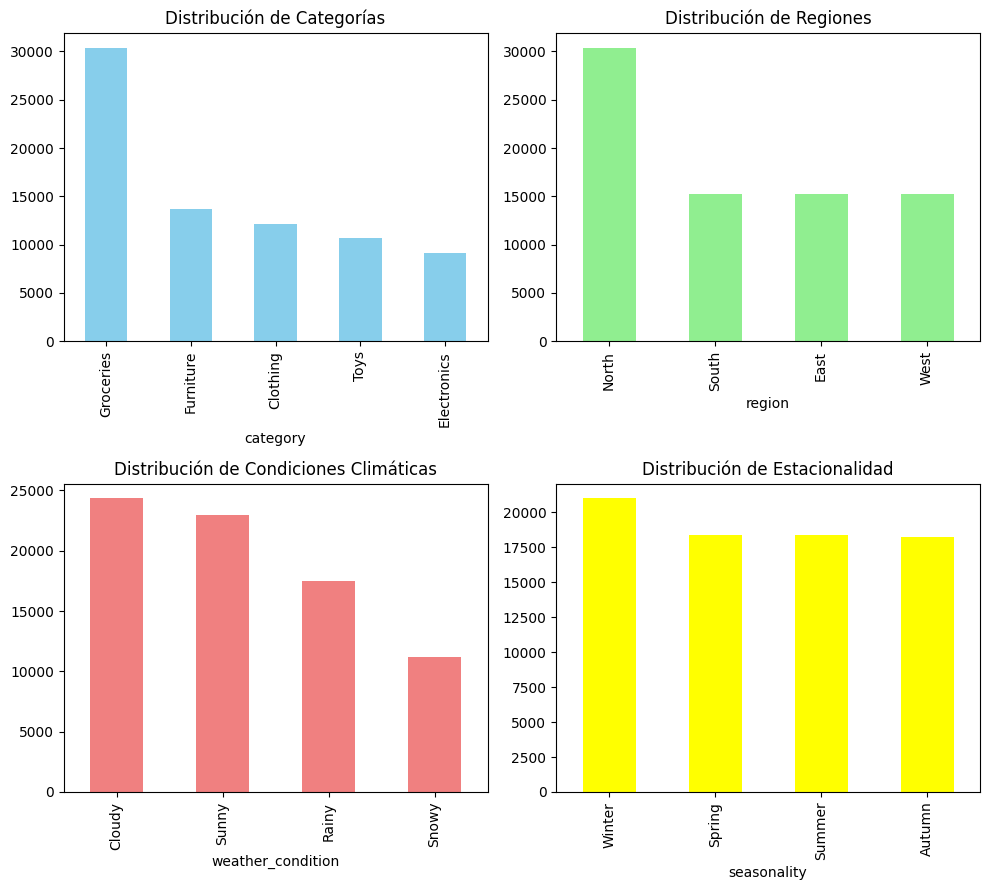

In [ ]:
# Crea el espacio de gráficos y sus ejes; puedes cambiar figsize para hacerlos más grandes o pequeños, y la cantidad de filas/columnas si ajustas axes.
fig,axs = plt.subplots(2,2, figsize=(10,9))

# Cuenta cuántas veces aparece cada valor de category; puedes cambiar la columna para analizar otra categoría.
df_cat['category'].value_counts().plot(kind='bar', ax=axs[0,0], title='Distribución de Categorías', color='skyblue')
# Cuenta cuántas veces aparece cada valor de region; puedes cambiar la columna para analizar otra categoría.
df_cat['region'].value_counts().plot(kind='bar', ax=axs[0,1], title='Distribución de Regiones', color='lightgreen')
# Cuenta cuántas veces aparece cada valor de weather_condition; puedes cambiar la columna para analizar otra categoría.
df_cat['weather_condition'].value_counts().plot(kind='bar', ax=axs[1,0], title='Distribución de Condiciones Climáticas', color='lightcoral')
# Cuenta cuántas veces aparece cada valor de seasonality; puedes cambiar la columna para analizar otra categoría.
df_cat['seasonality'].value_counts().plot(kind='bar', ax=axs[1,1], title='Distribución de Estacionalidad', color='yellow')
# Ajusta automáticamente espacios del gráfico para que no se encimen textos; no recomiendo quitarlo si hay muchas etiquetas.
plt.tight_layout()

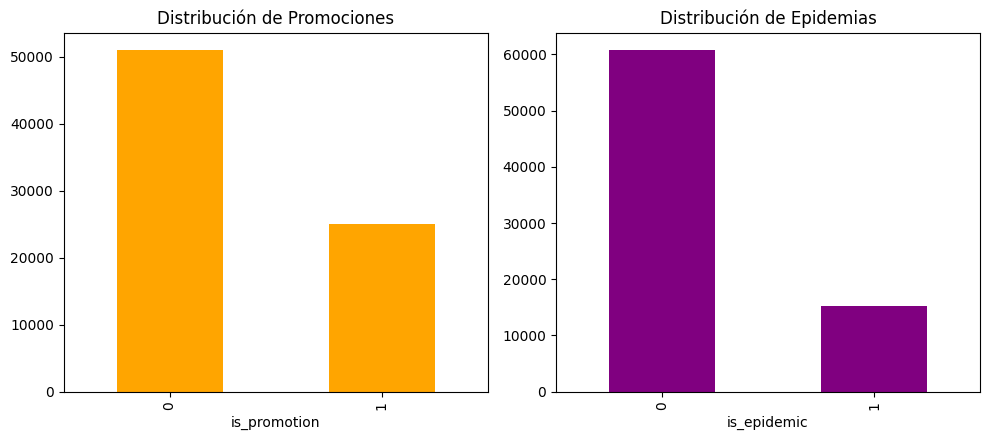

In [ ]:
# Crea el espacio de gráficos y sus ejes; puedes cambiar figsize para hacerlos más grandes o pequeños, y la cantidad de filas/columnas si ajustas axes.
fig, axs = plt.subplots(1, 2, figsize=(10, 4.5))

# Cuenta cuántas veces aparece cada valor de is_promotion; puedes cambiar la columna para analizar otra categoría.
df_cat['is_promotion'].value_counts().plot(kind='bar', ax=axs[0], title='Distribución de Promociones', color='orange')
# Cuenta cuántas veces aparece cada valor de is_epidemic; puedes cambiar la columna para analizar otra categoría.
df_cat['is_epidemic'].value_counts().plot(kind='bar', ax=axs[1], title='Distribución de Epidemias', color='purple')

# Ajusta automáticamente espacios del gráfico para que no se encimen textos; no recomiendo quitarlo si hay muchas etiquetas.
plt.tight_layout()
# Muestra el gráfico en pantalla; no cambia los datos, solo hace visible la visualización.
plt.show()

### 4.2 Análisis univariado — variables numéricas

Estadísticos descriptivos, histogramas, boxplots, percentiles y revisión de outliers generales del dataset.


In [ ]:
# Muestra columnas, tipos de datos y nulos de df_num; no cambia la data, solo ayuda a diagnosticar calidad y estructura.
df_num.info()

<class 'pandas.DataFrame'>
RangeIndex: 76000 entries, 0 to 75999
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   inventory_level     76000 non-null  int64  
 1   units_sold          76000 non-null  int64  
 2   units_ordered       76000 non-null  int64  
 3   price               76000 non-null  float64
 4   discount            76000 non-null  int64  
 5   competitor_pricing  76000 non-null  float64
 6   demand              76000 non-null  int64  
 7   year                76000 non-null  int32  
 8   month               76000 non-null  int32  
 9   day                 76000 non-null  int32  
dtypes: float64(2), int32(3), int64(5)
memory usage: 4.9 MB


In [ ]:
# Calcula estadísticas descriptivas como media, mínimos, máximos y cuartiles; puedes cambiar la columna para resumir otra variable.
df_num.describe().T

,count,mean,std,min,25%,50%,75%,max
inventory_level,76000.0,301.062842,226.510161,0.00,136.0000,227.0,408.0000,2267.00
units_sold,76000.0,88.827316,43.994525,0.00,58.0000,84.0,114.0000,426.00
units_ordered,76000.0,89.090645,162.404627,0.00,0.0000,0.0,121.0000,1616.00
price,76000.0,67.726028,39.377899,4.74,31.9975,64.5,95.8300,228.03
discount,76000.0,9.087039,7.475781,0.00,5.0000,10.0,10.0000,25.00
competitor_pricing,76000.0,69.454029,40.943818,4.29,32.6200,65.7,97.9325,261.22
demand,76000.0,104.317158,46.964801,4.00,71.0000,100.0,133.0000,430.00
year,76000.0,2022.559211,0.570479,2022.00,2022.0000,2023.0,2023.0000,2024.00
month,76000.0,6.307895,3.546325,1.00,3.0000,6.0,9.0000,12.00
day,76000.0,15.711842,8.790894,1.00,8.0000,16.0,23.0000,31.00


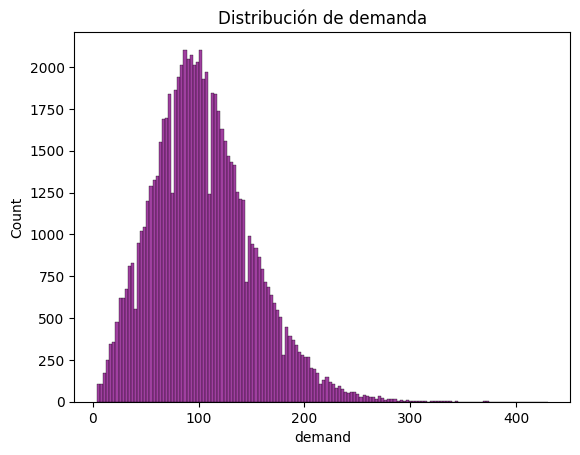

In [135]:
# Crea el espacio de gráficos y sus ejes; puedes cambiar figsize para hacerlos más grandes o pequeños, y la cantidad de filas/columnas si ajustas axes.
fig, ax = plt.subplots()
# Crea un histograma para ver distribución de una variable; puedes cambiar x, bins o color, y cambiará la columna, detalle o color del gráfico.
sns.histplot(data=df_num, x='demand', color="purple")
# Coloca el título del gráfico para explicar qué se está mostrando; puedes cambiar el texto o fontsize sin afectar los datos.
ax.set_title("Distribución de demanda")
plt.show()

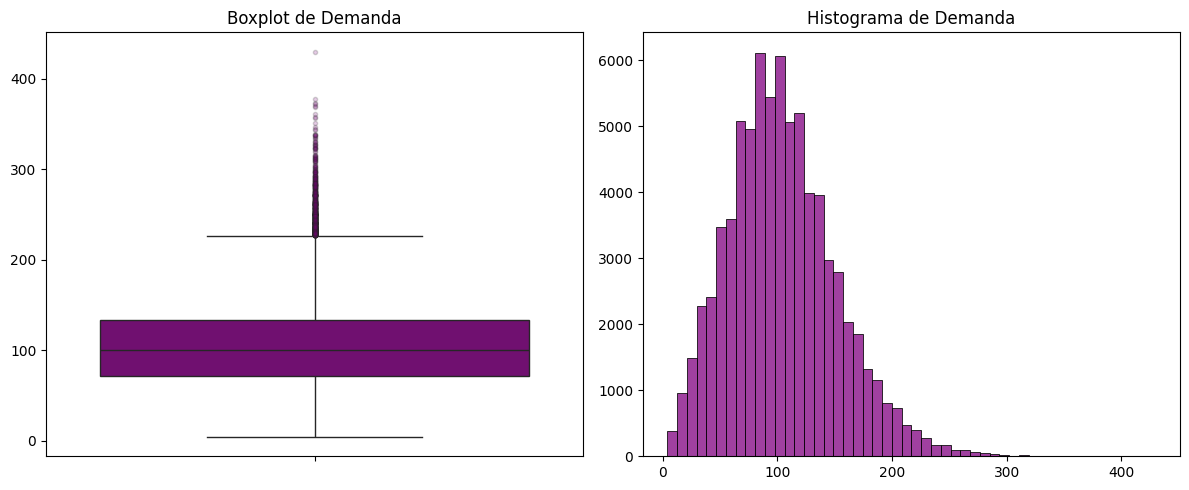

In [ ]:
# Crea el espacio de gráficos y sus ejes; puedes cambiar figsize para hacerlos más grandes o pequeños, y la cantidad de filas/columnas si ajustas axes.
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
# Crea un boxplot para ver mediana, dispersión y posibles outliers; puedes cambiar x/y, data o color para analizar otra variable.
sns.boxplot(data=df_num, y='demand', ax=axes[0], color='purple',
    # Configura cómo se ven los puntos atípicos del boxplot; puedes cambiar marker, color, alpha o markersize para modificar apariencia.
    flierprops=dict(marker='o', markerfacecolor='purple', alpha=0.2, markersize=3))
# Crea un histograma para ver distribución de una variable; puedes cambiar x, bins o color, y cambiará la columna, detalle o color del gráfico.
sns.histplot(data=df_num, x='demand', bins=50, ax=axes[1], color='purple')
# Coloca el título del gráfico para explicar qué se está mostrando; puedes cambiar el texto o fontsize sin afectar los datos.
axes[0].set_title('Boxplot de Demanda')
# Coloca el título del gráfico para explicar qué se está mostrando; puedes cambiar el texto o fontsize sin afectar los datos.
axes[1].set_title('Histograma de Demanda')

# Define la etiqueta del eje X; puedes cambiar el texto para que la exposición sea más clara, sin afectar los cálculos.
axes[0].set_xlabel('')
# Define la etiqueta del eje Y; puedes cambiar el texto para explicar mejor la variable, sin afectar los cálculos.
axes[0].set_ylabel('')
# Define la etiqueta del eje X; puedes cambiar el texto para que la exposición sea más clara, sin afectar los cálculos.
axes[1].set_xlabel('')
# Define la etiqueta del eje Y; puedes cambiar el texto para explicar mejor la variable, sin afectar los cálculos.
axes[1].set_ylabel('')

plt.tight_layout()

In [136]:
# Calcula el percentil 0.25 de demand; puedes cambiar ese valor entre 0 y 1, y el corte de análisis se moverá.
print(f"Percentil 25: {df['demand'].quantile(0.25):.2f}")
# Calcula el percentil 0.50 de demand; puedes cambiar ese valor entre 0 y 1, y el corte de análisis se moverá.
print(f"Percentil 50: {df['demand'].quantile(0.50):.2f}")
# Calcula el percentil 0.75 de demand; puedes cambiar ese valor entre 0 y 1, y el corte de análisis se moverá.
print(f"Percentil 75: {df['demand'].quantile(0.75):.2f}")
# Calcula el percentil 0.99 de demand; puedes cambiar ese valor entre 0 y 1, y el corte de análisis se moverá.
print(f"Percentil 99: {df['demand'].quantile(0.99):.2f}")

# Define la lista de percentiles que se van a revisar; puedes agregar o quitar valores para observar más o menos cortes.
percentiles = [1, 5, 10, 20, 25, 50, 75, 80, 90, 95, 97.5, 99, 99.9, 99.99, 100]
# Calcula el percentil p / 100 de demand; puedes cambiar ese valor entre 0 y 1, y el corte de análisis se moverá.
datos = [(p, df_num['demand'].quantile(p / 100)) for p in percentiles]
print(pd.DataFrame(datos, columns=["Percentil", "Valor"]).round(2))

Percentil 25: 71.00
Percentil 50: 100.00
Percentil 75: 133.00
Percentil 99: 234.00
    Percentil  Valor
0        1.00   17.0
1        5.00   34.0
2       10.00   47.0
3       20.00   65.0
4       25.00   71.0
5       50.00  100.0
6       75.00  133.0
7       80.00  141.0
8       90.00  166.0
9       95.00  188.0
10      97.50  208.0
11      99.00  234.0
12      99.90  295.0
13      99.99  357.4
14     100.00  430.0


In [ ]:
# Calcula el percentil 0.25 de demand; puedes cambiar ese valor entre 0 y 1, y el corte de análisis se moverá.
q1 = df_num['demand'].quantile(0.25)
# Calcula el percentil 0.75 de demand; puedes cambiar ese valor entre 0 y 1, y el corte de análisis se moverá.
q3 = df_num['demand'].quantile(0.75)
# Calcula el rango intercuartílico restando Q1 a Q3; no recomiendo cambiar esta fórmula porque es la base del método IQR.
iqr = q3 - q1

# Calcula el límite inferior para detectar outliers; puedes cambiar 1.5 para ser más o menos estricto.
limite_inferior = q1 - 1.5 * iqr
# Calcula el límite superior para detectar outliers; si subes 1.5 habrá menos outliers, si lo bajas habrá más.
limite_superior = q3 + 1.5 * iqr

# Imprime un resultado para revisarlo en la salida; puedes cambiar el texto, pero evita cambiar variables si quieres conservar la lógica.
print(f"Q1: {q1:.2f}")
# Imprime un resultado para revisarlo en la salida; puedes cambiar el texto, pero evita cambiar variables si quieres conservar la lógica.
print(f"Q3: {q3:.2f}")
# Imprime un resultado para revisarlo en la salida; puedes cambiar el texto, pero evita cambiar variables si quieres conservar la lógica.
print(f"IQR: {iqr:.2f}")
# Imprime un resultado para revisarlo en la salida; puedes cambiar el texto, pero evita cambiar variables si quieres conservar la lógica.
print(f"Limite inferior: {limite_inferior:.2f}")
# Imprime un resultado para revisarlo en la salida; puedes cambiar el texto, pero evita cambiar variables si quieres conservar la lógica.
print(f"Limite superior: {limite_superior:.2f}")
# Imprime un resultado para revisarlo en la salida; puedes cambiar el texto, pero evita cambiar variables si quieres conservar la lógica.
print(f"Cantidad de valores por debajo del límite inferior: {(df_num['demand'] < limite_inferior).sum()}")
# Imprime un resultado para revisarlo en la salida; puedes cambiar el texto, pero evita cambiar variables si quieres conservar la lógica.
print(f"Cantidad de valores por encima del límite superior: {(df_num['demand'] > limite_superior).sum()}")

Q1: 71.00
Q3: 133.00
IQR: 62.00
Limite inferior: -22.00
Limite superior: 226.00
Cantidad de valores por debajo del límite inferior: 0
Cantidad de valores por encima del límite superior: 986


In [ ]:
# Crea una condición True/False para marcar demandas fuera de los límites; cambia 'demand' solo si analizarás otra variable.
condicion_outliers = (df_num['demand'] < limite_inferior) | (df_num['demand'] > limite_superior)
# Crea una condición True/False para marcar demandas fuera de los límites; cambia 'demand' solo si analizarás otra variable.
outliers = df_num[condicion_outliers]['demand'].sort_values(ascending=True)
# Imprime un resultado para revisarlo en la salida; puedes cambiar el texto, pero evita cambiar variables si quieres conservar la lógica.
print(f"Cantidad total de outliers: {outliers.shape[0]}")
# Imprime un resultado para revisarlo en la salida; puedes cambiar el texto, pero evita cambiar variables si quieres conservar la lógica.
print(outliers)

Cantidad total de outliers: 986
2672     227
353      227
56353    227
3720     227
55852    227
        ... 
60261    370
53415    372
21885    373
21915    378
54387    430
Name: demand, Length: 986, dtype: int64


In [ ]:
# Define una función para detectar outliers usando media y desviación estándar; puedes cambiar threshold al llamarla, no el nombre si se usa después.
def std_outliers(data, threshold=3):
    # Calcula la media de los datos para usarla como centro de referencia; no conviene cambiar mean() si el método es de desviación estándar.
    mu = data.mean()
    # Calcula la desviación estándar para medir dispersión; si cambias std() el método de outliers dejaría de ser el esperado.
    std = data.std()
    # Calcula el límite superior usando media más threshold por desviación; cambia threshold al llamar la función para ajustar sensibilidad.
    lim_superior = mu + threshold * std
    # Calcula el límite inferior usando media menos threshold por desviación; si bajas threshold, aparecerán más outliers.
    lim_inferior = mu - threshold * std
    # Calcula el límite superior usando media más threshold por desviación; cambia threshold al llamar la función para ajustar sensibilidad.
    outliers = data[(data < lim_inferior) | (data > lim_superior)]
    # Imprime un resultado para revisarlo en la salida; puedes cambiar el texto, pero evita cambiar variables si quieres conservar la lógica.
    print(f"Media: {mu:.2f}")
    # Imprime un resultado para revisarlo en la salida; puedes cambiar el texto, pero evita cambiar variables si quieres conservar la lógica.
    print(f"Desviación estándar: {std:.2f}")
    # Imprime un resultado para revisarlo en la salida; puedes cambiar el texto, pero evita cambiar variables si quieres conservar la lógica.
    print(f"Limite inferior: {lim_inferior:.2f}")
    # Imprime un resultado para revisarlo en la salida; puedes cambiar el texto, pero evita cambiar variables si quieres conservar la lógica.
    print(f"Limite superior: {lim_superior:.2f}")
    # Imprime un resultado para revisarlo en la salida; puedes cambiar el texto, pero evita cambiar variables si quieres conservar la lógica.
    print(f"Cantidad de outliers: {outliers.shape[0]}")
    # Devuelve el resultado de la función para usarlo fuera del bloque; no recomiendo quitar return porque perderías la salida.
    return outliers.sort_values(ascending=False)

In [ ]:
# Ejecuta la función de outliers y guarda el resultado; puedes cambiar threshold=3, menor detecta más outliers y mayor detecta menos.
outliers_std = std_outliers(df_num['demand'], threshold=3)

Media: 104.32
Desviación estándar: 46.96
Limite inferior: -36.58
Limite superior: 245.21
Cantidad de outliers: 517


In [ ]:
# Define una función para detectar outliers con Z-score; puedes cambiar threshold al usarla para ser más o menos estricto.
def outliers_zscore(data, threshold=3):
    # Documenta brevemente la función; puedes cambiar el texto, pero no afecta los resultados.
    """Detecta outliers usando Z-score."""
    # Calcula la media de los datos para usarla como centro de referencia; no conviene cambiar mean() si el método es de desviación estándar.
    mu = data.mean()
    # Calcula la desviación estándar para medir dispersión; si cambias std() el método de outliers dejaría de ser el esperado.
    std = data.std()
    # Crea una lista vacía para guardar valores detectados como outliers; no recomiendo cambiarla porque la función la llena después.
    resultados = []
    # Recorre elementos para aplicar la misma acción a cada valor, producto o gráfico; puedes cambiar la fuente del recorrido si entiendes la estructura.
    for valor in data:
        # Calcula qué tan lejos está un valor de la media en unidades de desviación estándar; no recomiendo tocar la fórmula del Z-score.
        z = (valor - mu) / std
        # Evalúa una condición para decidir qué datos cumplen el criterio; cambiar el operador puede incluir o excluir registros diferentes.
        if np.abs(z) > threshold:
            # Agrega un resultado a la lista para construir una tabla final; puedes cambiar etiquetas del diccionario, pero actualiza el resto si las usas.
            resultados.append({"valor": valor, "zscore": round(z, 3)})
    # Convierte la lista de outliers en una tabla para verla mejor; no cambia la data original.
    df_outliers = pd.DataFrame(resultados)
    # Evalúa una condición para decidir qué datos cumplen el criterio; cambiar el operador puede incluir o excluir registros diferentes.
    if len(df_outliers) > 0:
        # Ordena los resultados para ver primero mayores o menores; puedes cambiar ascending para invertir el orden.
        df_outliers = df_outliers.sort_values("zscore", ascending=False)
    # Imprime un resultado para revisarlo en la salida; puedes cambiar el texto, pero evita cambiar variables si quieres conservar la lógica.
    print(f"Outliers con |z| > {threshold}: {len(df_outliers)}")
    return df_outliers

In [ ]:
# Ejecuta la detección por Z-score; puedes cambiar threshold=3 para ajustar qué tan extremo debe ser un valor.
outliers_zscore(df_num['demand'], threshold=3)

Outliers con |z| > 3: 517


,valor,zscore
351,430,6.935
146,378,5.827
145,373,5.721
330,372,5.700
468,370,5.657
...,...,...
385,246,3.017
105,246,3.017
441,246,3.017
126,246,3.017


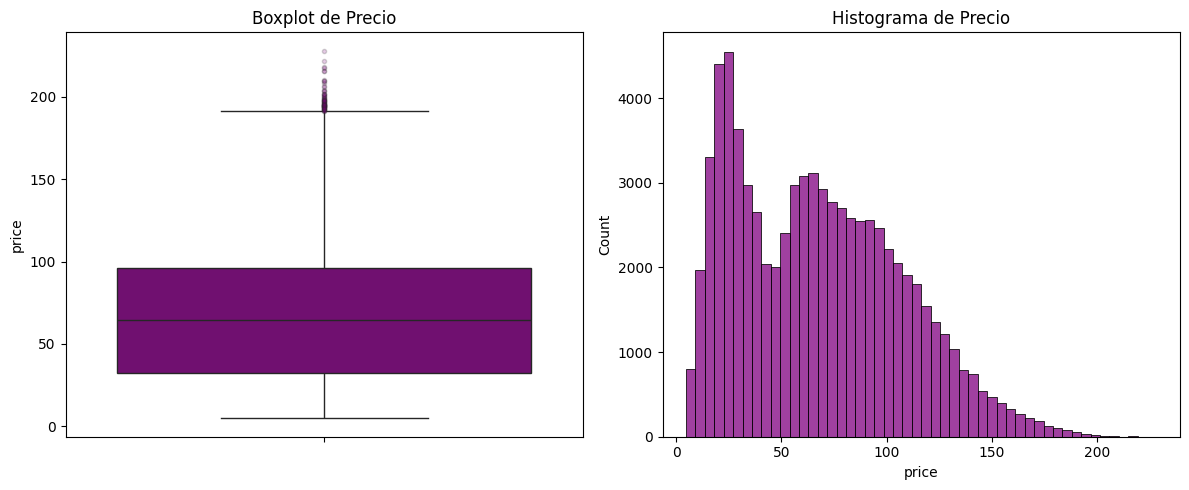

In [ ]:
# Crea el espacio de gráficos y sus ejes; puedes cambiar figsize para hacerlos más grandes o pequeños, y la cantidad de filas/columnas si ajustas axes.
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
# Crea un boxplot para ver mediana, dispersión y posibles outliers; puedes cambiar x/y, data o color para analizar otra variable.
sns.boxplot(data=df_num, y='price', ax=axes[0], color='purple',
    # Configura cómo se ven los puntos atípicos del boxplot; puedes cambiar marker, color, alpha o markersize para modificar apariencia.
    flierprops=dict(marker='o', markerfacecolor='purple', alpha=0.2, markersize=3))
# Crea un histograma para ver distribución de una variable; puedes cambiar x, bins o color, y cambiará la columna, detalle o color del gráfico.
sns.histplot(data=df_num, x='price', bins=50, ax=axes[1], color='purple')
# Coloca el título del gráfico para explicar qué se está mostrando; puedes cambiar el texto o fontsize sin afectar los datos.
axes[0].set_title('Boxplot de Precio')
# Coloca el título del gráfico para explicar qué se está mostrando; puedes cambiar el texto o fontsize sin afectar los datos.
axes[1].set_title('Histograma de Precio')

plt.tight_layout()

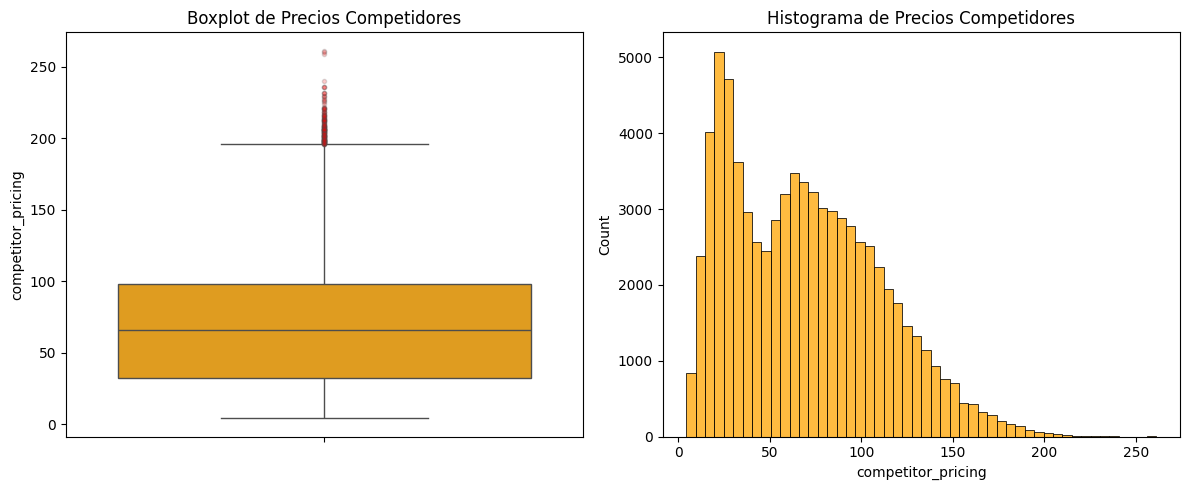

In [ ]:
# Crea el espacio de gráficos y sus ejes; puedes cambiar figsize para hacerlos más grandes o pequeños, y la cantidad de filas/columnas si ajustas axes.
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
# Crea un boxplot para ver mediana, dispersión y posibles outliers; puedes cambiar x/y, data o color para analizar otra variable.
sns.boxplot(data=df_num, y='competitor_pricing', ax=axes[0], color='orange',
    # Configura cómo se ven los puntos atípicos del boxplot; puedes cambiar marker, color, alpha o markersize para modificar apariencia.
    flierprops=dict(marker='o', markerfacecolor='red', alpha=0.2, markersize=3))
# Crea un histograma para ver distribución de una variable; puedes cambiar x, bins o color, y cambiará la columna, detalle o color del gráfico.
sns.histplot(data=df_num, x='competitor_pricing', bins=50, ax=axes[1], color='orange')
# Coloca el título del gráfico para explicar qué se está mostrando; puedes cambiar el texto o fontsize sin afectar los datos.
axes[0].set_title('Boxplot de Precios Competidores')
# Coloca el título del gráfico para explicar qué se está mostrando; puedes cambiar el texto o fontsize sin afectar los datos.
axes[1].set_title('Histograma de Precios Competidores')

plt.tight_layout()

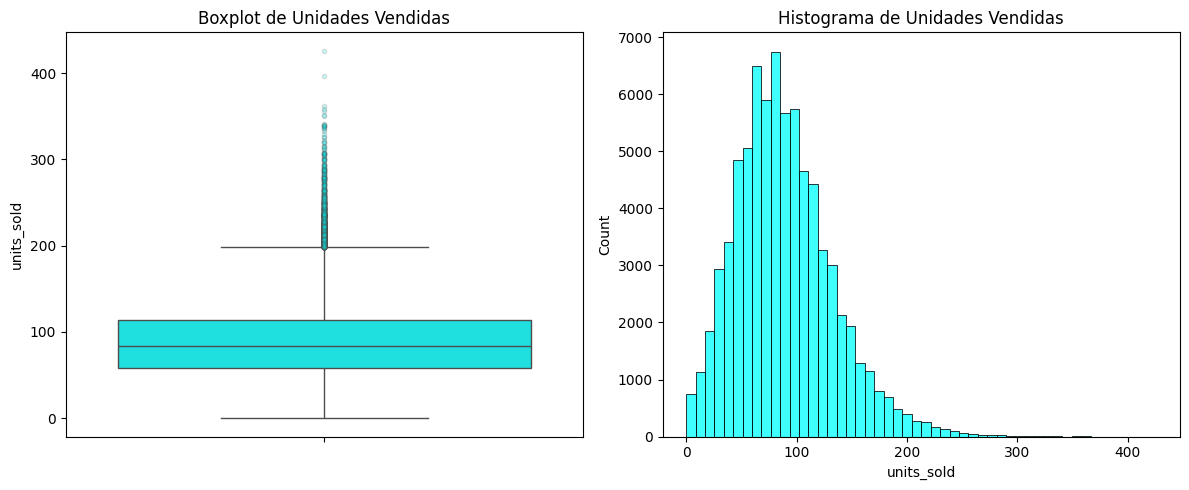

In [ ]:
# Crea el espacio de gráficos y sus ejes; puedes cambiar figsize para hacerlos más grandes o pequeños, y la cantidad de filas/columnas si ajustas axes.
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
# Crea un boxplot para ver mediana, dispersión y posibles outliers; puedes cambiar x/y, data o color para analizar otra variable.
sns.boxplot(data=df_num, y='units_sold', ax=axes[0], color='cyan',
    # Configura cómo se ven los puntos atípicos del boxplot; puedes cambiar marker, color, alpha o markersize para modificar apariencia.
    flierprops=dict(marker='o', markerfacecolor='cyan', alpha=0.2, markersize=3))
# Crea un histograma para ver distribución de una variable; puedes cambiar x, bins o color, y cambiará la columna, detalle o color del gráfico.
sns.histplot(data=df_num, x='units_sold', bins=50, ax=axes[1], color='cyan')
# Coloca el título del gráfico para explicar qué se está mostrando; puedes cambiar el texto o fontsize sin afectar los datos.
axes[0].set_title('Boxplot de Unidades Vendidas')
# Coloca el título del gráfico para explicar qué se está mostrando; puedes cambiar el texto o fontsize sin afectar los datos.
axes[1].set_title('Histograma de Unidades Vendidas')

plt.tight_layout()

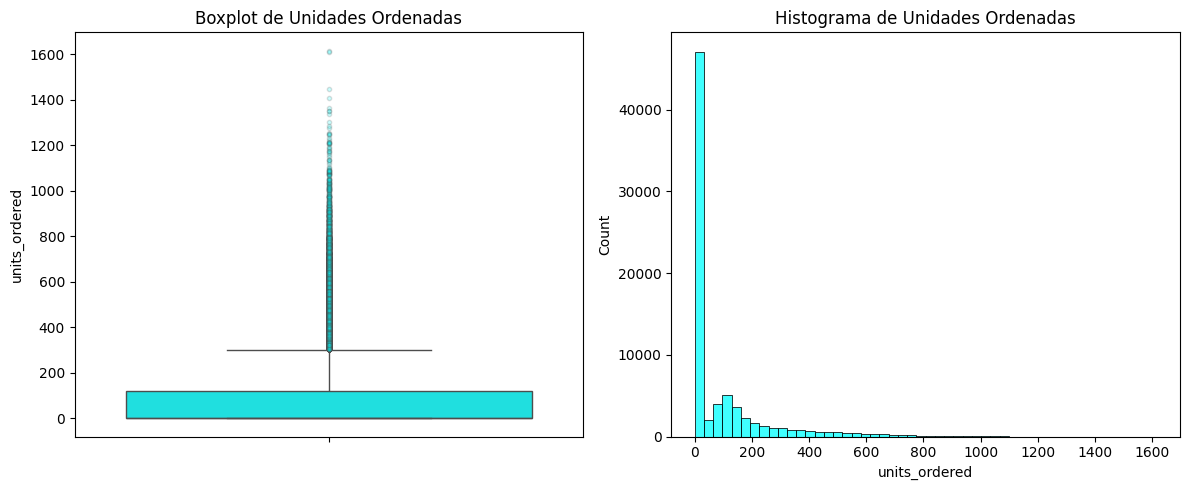

In [ ]:
# Crea el espacio de gráficos y sus ejes; puedes cambiar figsize para hacerlos más grandes o pequeños, y la cantidad de filas/columnas si ajustas axes.
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
# Crea un boxplot para ver mediana, dispersión y posibles outliers; puedes cambiar x/y, data o color para analizar otra variable.
sns.boxplot(data=df_num, y='units_ordered', ax=axes[0], color='cyan',
    # Configura cómo se ven los puntos atípicos del boxplot; puedes cambiar marker, color, alpha o markersize para modificar apariencia.
    flierprops=dict(marker='o', markerfacecolor='cyan', alpha=0.2, markersize=3))
# Crea un histograma para ver distribución de una variable; puedes cambiar x, bins o color, y cambiará la columna, detalle o color del gráfico.
sns.histplot(data=df_num, x='units_ordered', bins=50, ax=axes[1], color='cyan')
# Coloca el título del gráfico para explicar qué se está mostrando; puedes cambiar el texto o fontsize sin afectar los datos.
axes[0].set_title('Boxplot de Unidades Ordenadas')
# Coloca el título del gráfico para explicar qué se está mostrando; puedes cambiar el texto o fontsize sin afectar los datos.
axes[1].set_title('Histograma de Unidades Ordenadas')

plt.tight_layout()

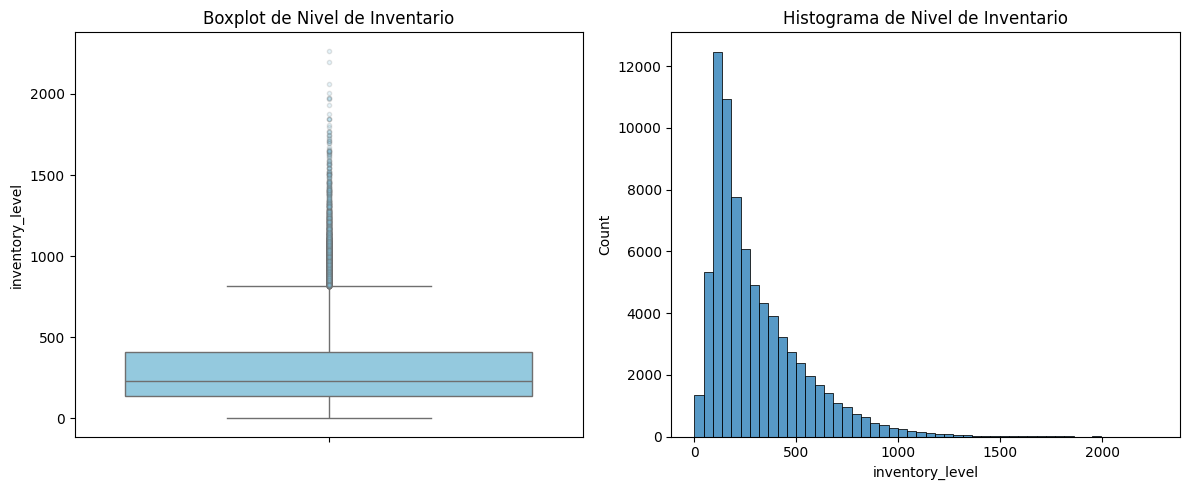

In [ ]:
# Crea el espacio de gráficos y sus ejes; puedes cambiar figsize para hacerlos más grandes o pequeños, y la cantidad de filas/columnas si ajustas axes.
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
# Crea un boxplot para ver mediana, dispersión y posibles outliers; puedes cambiar x/y, data o color para analizar otra variable.
sns.boxplot(data=df_num, y='inventory_level', ax=axes[0], color='skyblue',
    # Configura cómo se ven los puntos atípicos del boxplot; puedes cambiar marker, color, alpha o markersize para modificar apariencia.
    flierprops=dict(marker='o', markerfacecolor='skyblue', alpha=0.2, markersize=3))
# Crea un histograma para ver distribución de una variable; puedes cambiar x, bins o color, y cambiará la columna, detalle o color del gráfico.
sns.histplot(data=df_num, x='inventory_level', bins=50, ax=axes[1])
# Coloca el título del gráfico para explicar qué se está mostrando; puedes cambiar el texto o fontsize sin afectar los datos.
axes[0].set_title('Boxplot de Nivel de Inventario')
# Coloca el título del gráfico para explicar qué se está mostrando; puedes cambiar el texto o fontsize sin afectar los datos.
axes[1].set_title('Histograma de Nivel de Inventario')

plt.tight_layout()

C:\Users\syrri\AppData\Local\Temp\ipykernel_40336\184301151.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_num, x='discount', ax=ax, palette='rocket')


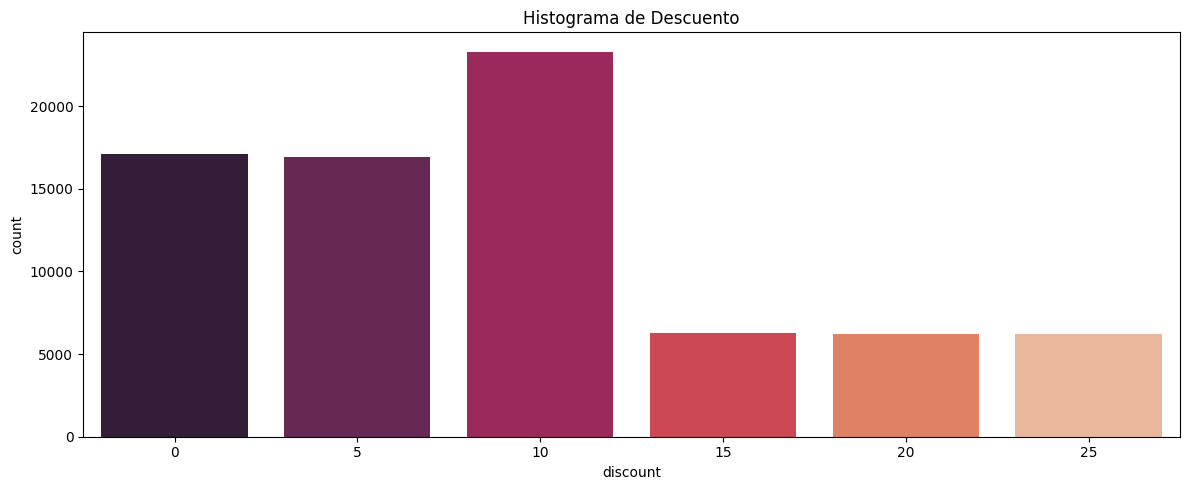

In [ ]:
# Crea el espacio de gráficos y sus ejes; puedes cambiar figsize para hacerlos más grandes o pequeños, y la cantidad de filas/columnas si ajustas axes.
fig, ax = plt.subplots(figsize=(12, 5))
# Crea un conteo gráfico de categorías o valores repetidos; puedes cambiar x, palette o data para revisar otra variable.
sns.countplot(data=df_num, x='discount', ax=ax, palette='rocket')
# Coloca el título del gráfico para explicar qué se está mostrando; puedes cambiar el texto o fontsize sin afectar los datos.
ax.set_title('Boxplot de Descuento')
# Coloca el título del gráfico para explicar qué se está mostrando; puedes cambiar el texto o fontsize sin afectar los datos.
ax.set_title('Histograma de Descuento')

plt.tight_layout()

In [ ]:
# Calcula la moda, es decir, el valor más frecuente; puedes cambiar el DataFrame o columna para buscar otra moda.
df_cat.mode()

,date,store_id,product_id,category,region,weather_condition,is_promotion,seasonality,is_epidemic,day_of_week
0,2022-01-01,S001,P0001,Groceries,North,Cloudy,0,Winter,0,Monday
1,2022-01-02,S002,P0002,NaN,NaN,NaN,NaN,NaN,NaN,Saturday
2,2022-01-03,S003,P0003,NaN,NaN,NaN,NaN,NaN,NaN,Sunday
3,2022-01-04,S004,P0004,NaN,NaN,NaN,NaN,NaN,NaN,Tuesday
4,2022-01-05,S005,P0005,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
755,2024-01-26,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
756,2024-01-27,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
757,2024-01-28,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
758,2024-01-29,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Calcula la moda, es decir, el valor más frecuente; puedes cambiar el DataFrame o columna para buscar otra moda.
df_num.mode()

,inventory_level,units_sold,units_ordered,price,discount,competitor_pricing,demand,year,month,day
0,0.0,72.0,0.0,23.34,10.0,27.02,88.0,2022.0,1.0,1
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2023.0,NaN,2
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6
6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7
7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8
8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9
9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10


### 4.3 Análisis temporal general

Visualización de la demanda agregada por fecha, año, mes y día de semana.


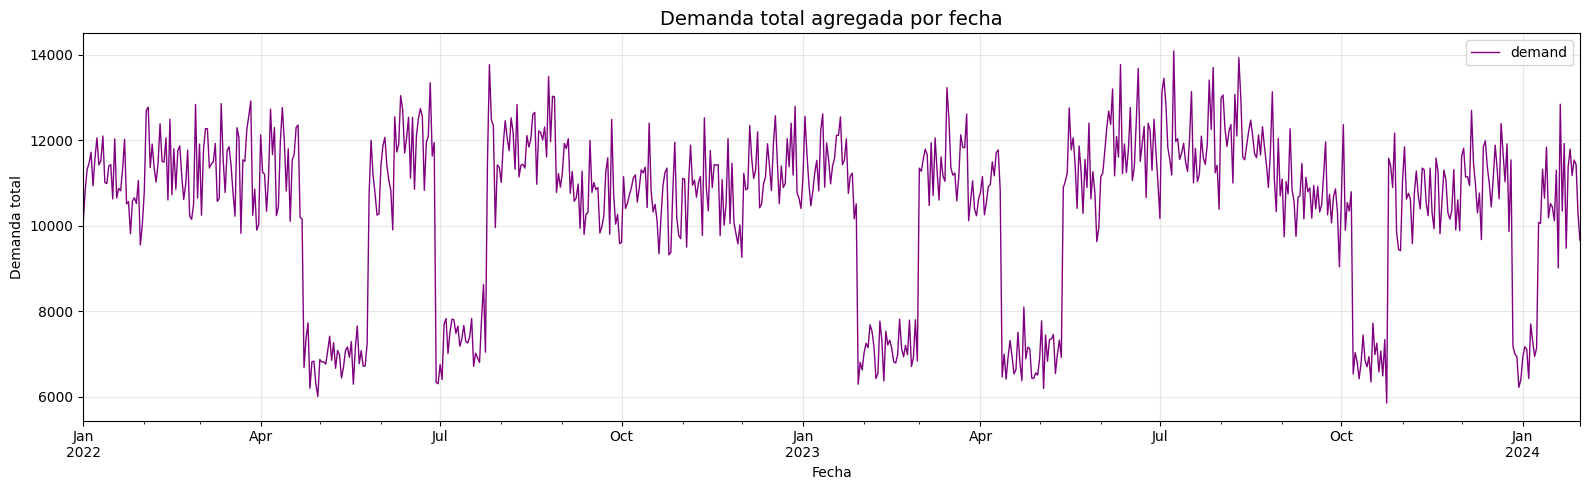

In [ ]:
# Agrupa datos por una columna para resumir demanda, precio u otra métrica; puedes cambiar la columna de groupby para otra comparación.
demand_diaria = df.groupby('date')['demand'].sum()

# Crea el espacio de gráficos y sus ejes; puedes cambiar figsize para hacerlos más grandes o pequeños, y la cantidad de filas/columnas si ajustas axes.
fig, ax = plt.subplots(figsize=(16, 5))
# Dibuja un gráfico con pandas sobre datos agrupados o conteos; puedes cambiar kind, color o title para modificar la visualización.
demand_diaria.plot(ax=ax, color='purple', linewidth=1)

# Coloca el título del gráfico para explicar qué se está mostrando; puedes cambiar el texto o fontsize sin afectar los datos.
ax.set_title('Demanda total agregada por fecha', fontsize=14)
# Define la etiqueta del eje X; puedes cambiar el texto para que la exposición sea más clara, sin afectar los cálculos.
ax.set_xlabel('Fecha')
# Define la etiqueta del eje Y; puedes cambiar el texto para explicar mejor la variable, sin afectar los cálculos.
ax.set_ylabel('Demanda total')
# Muestra la leyenda del gráfico; puedes cambiar loc para moverla, pero no afecta los datos.
ax.legend()
# Agrega líneas de guía al gráfico; puedes cambiar alpha para hacerlas más suaves o fuertes.
ax.grid(alpha=0.3)
# Ajusta automáticamente espacios del gráfico para que no se encimen textos; no recomiendo quitarlo si hay muchas etiquetas.
plt.tight_layout()

plt.show()

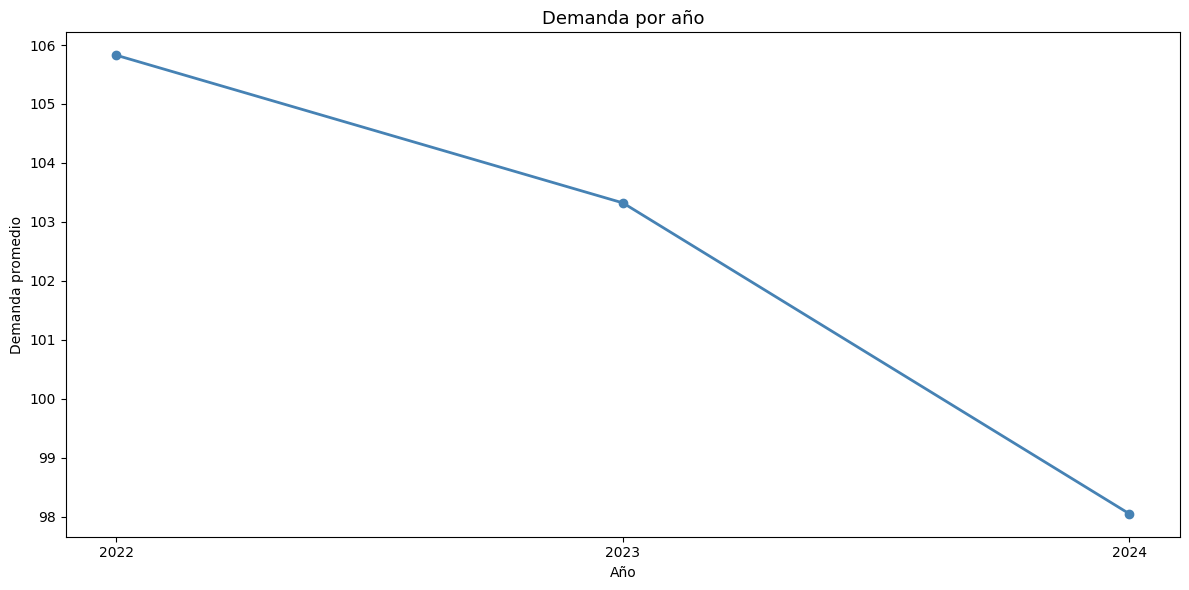

In [ ]:
# Crea el espacio de gráficos y sus ejes; puedes cambiar figsize para hacerlos más grandes o pequeños, y la cantidad de filas/columnas si ajustas axes.
fig, ax = plt.subplots(figsize=(12, 6))

# Agrupa datos y devuelve una tabla normal con índices reiniciados; puedes cambiar la columna de agrupación o la métrica si existe.
year_stats = df.groupby('year')['demand'].mean().reset_index()
# Crea o actualiza la variable 'ax.plot(year_stats['year'], year_stats['demand'], marker' para usarla en pasos posteriores; puedes cambiar el valor de la derecha, pero revisa que no rompa celdas siguientes.
ax.plot(year_stats['year'], year_stats['demand'], marker='o', color='steelblue', linewidth=2)
# Coloca el título del gráfico para explicar qué se está mostrando; puedes cambiar el texto o fontsize sin afectar los datos.
ax.set_title('Demanda por año', fontsize=13)
# Define la etiqueta del eje X; puedes cambiar el texto para que la exposición sea más clara, sin afectar los cálculos.
ax.set_xlabel('Año')
# Define la etiqueta del eje Y; puedes cambiar el texto para explicar mejor la variable, sin afectar los cálculos.
ax.set_ylabel('Demanda promedio')
# Define qué valores aparecen marcados en el eje X; cámbialo solo si también entiendes qué rango o categorías se mostrarán.
ax.set_xticks(year_stats['year'])

plt.tight_layout()

plt.show()

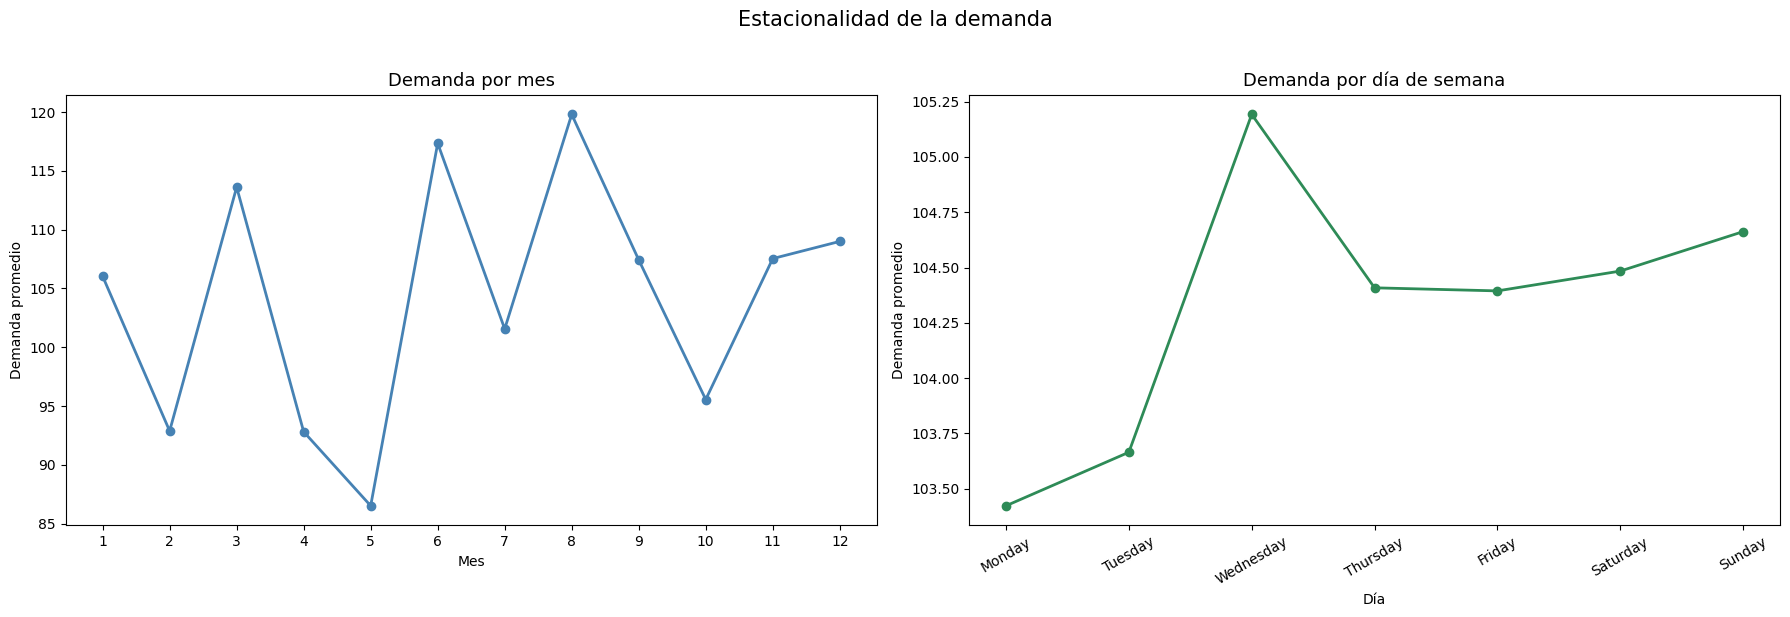

In [ ]:
# Crea o actualiza la variable 'orden_dias' para usarla en pasos posteriores; puedes cambiar el valor de la derecha, pero revisa que no rompa celdas siguientes.
orden_dias = ['Monday', 'Tuesday', 'Wednesday', 'Thursday',
              # Ejecuta esta línea dentro del análisis; cambia solo valores visibles como columnas, textos o colores si entiendes dónde se usan después.
              'Friday', 'Saturday', 'Sunday']

# Crea el espacio de gráficos y sus ejes; puedes cambiar figsize para hacerlos más grandes o pequeños, y la cantidad de filas/columnas si ajustas axes.
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Comentario de apoyo: esta línea ya es un comentario sobre 'Demanda por mes'; puedes mejorar el texto, pero no afecta los cálculos.
# Demanda por mes
# Agrupa datos y devuelve una tabla normal con índices reiniciados; puedes cambiar la columna de agrupación o la métrica si existe.
mes_stats = df.groupby('month')['demand'].mean().reset_index()
# Dibuja un gráfico con pandas sobre datos agrupados o conteos; puedes cambiar kind, color o title para modificar la visualización.
axes[0].plot(mes_stats['month'], mes_stats['demand'], marker='o', color='steelblue', linewidth=2)
# Coloca el título del gráfico para explicar qué se está mostrando; puedes cambiar el texto o fontsize sin afectar los datos.
axes[0].set_title('Demanda por mes', fontsize=13)
# Define la etiqueta del eje X; puedes cambiar el texto para que la exposición sea más clara, sin afectar los cálculos.
axes[0].set_xlabel('Mes')
# Define la etiqueta del eje Y; puedes cambiar el texto para explicar mejor la variable, sin afectar los cálculos.
axes[0].set_ylabel('Demanda promedio')
# Define qué valores aparecen marcados en el eje X; cámbialo solo si también entiendes qué rango o categorías se mostrarán.
axes[0].set_xticks(mes_stats['month'])

# Comentario de apoyo: esta línea ya es un comentario sobre 'Demanda por día de semana'; puedes mejorar el texto, pero no afecta los cálculos.
# Demanda por día de semana
# Agrupa datos y devuelve una tabla normal con índices reiniciados; puedes cambiar la columna de agrupación o la métrica si existe.
dia_stats = df.groupby('day_of_week')['demand'].mean().reindex(orden_dias).reset_index()
# Dibuja un gráfico con pandas sobre datos agrupados o conteos; puedes cambiar kind, color o title para modificar la visualización.
axes[1].plot(range(len(orden_dias)), dia_stats['demand'], marker='o', color='seagreen', linewidth=2)
# Define qué valores aparecen marcados en el eje X; cámbialo solo si también entiendes qué rango o categorías se mostrarán.
axes[1].set_xticks(range(len(orden_dias)))
# Cambia los textos visibles del eje X; puedes modificar rotation para girar etiquetas y evitar que se monten.
axes[1].set_xticklabels(orden_dias, rotation=30)
# Coloca el título del gráfico para explicar qué se está mostrando; puedes cambiar el texto o fontsize sin afectar los datos.
axes[1].set_title('Demanda por día de semana', fontsize=13)
# Define la etiqueta del eje X; puedes cambiar el texto para que la exposición sea más clara, sin afectar los cálculos.
axes[1].set_xlabel('Día')
# Define la etiqueta del eje Y; puedes cambiar el texto para explicar mejor la variable, sin afectar los cálculos.
axes[1].set_ylabel('Demanda promedio')


plt.suptitle('Estacionalidad de la demanda', fontsize=15, y=1.02)

plt.tight_layout()

plt.show()

### 4.4 Análisis bivariado — relación con la demanda

Relación de `demand` con variables numéricas, categóricas, producto, tienda, precio y correlaciones.


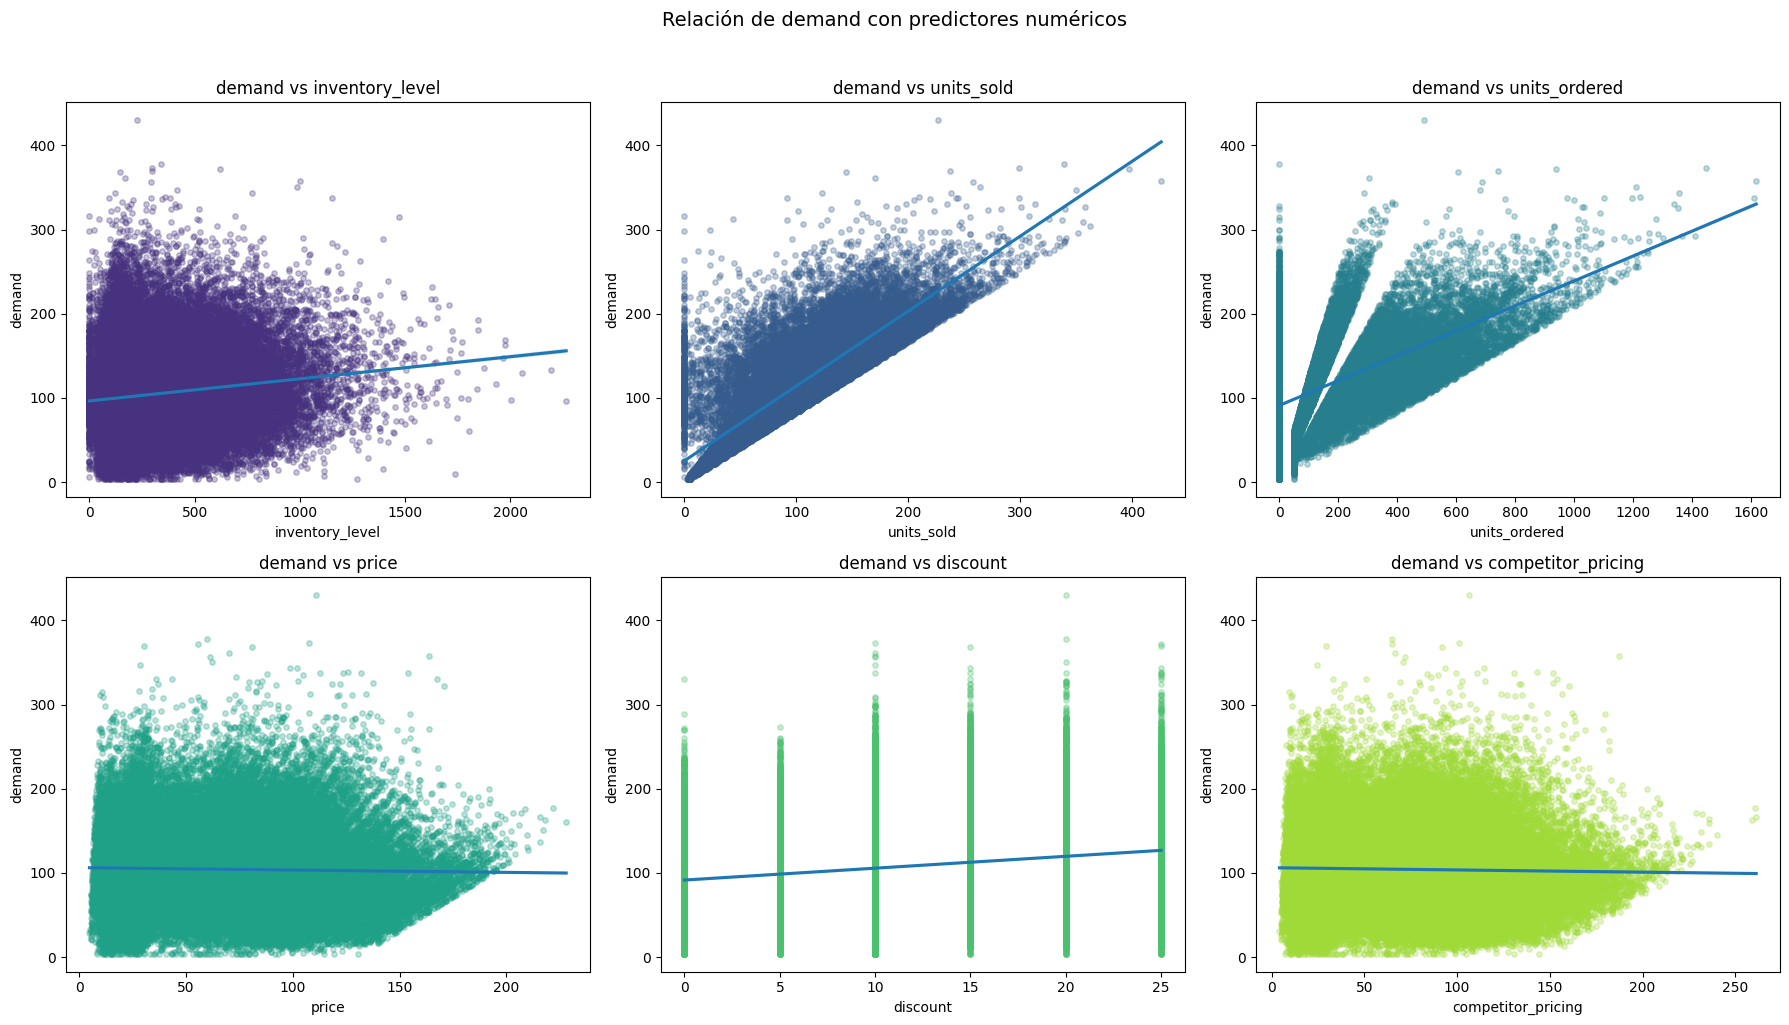

In [ ]:
# Crea o actualiza la variable 'predictores_num' para usarla en pasos posteriores; puedes cambiar el valor de la derecha, pero revisa que no rompa celdas siguientes.
predictores_num = [c for c in df_num.columns if c not in ['demand', 'year', 'month', 'day']]
# Crea o actualiza la variable 'colores' para usarla en pasos posteriores; puedes cambiar el valor de la derecha, pero revisa que no rompa celdas siguientes.
colores = sns.color_palette("viridis", 6)

# Crea el espacio de gráficos y sus ejes; puedes cambiar figsize para hacerlos más grandes o pequeños, y la cantidad de filas/columnas si ajustas axes.
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Recorre elementos para aplicar la misma acción a cada valor, producto o gráfico; puedes cambiar la fuente del recorrido si entiendes la estructura.
for ax, col, color in zip(axes.flatten(), predictores_num, colores):
    # Crea un gráfico de dispersión con línea de tendencia; puedes cambiar x o y para comparar otra variable contra la demanda.
    sns.regplot(
        # Crea o actualiza la variable 'data' para usarla en pasos posteriores; puedes cambiar el valor de la derecha, pero revisa que no rompa celdas siguientes.
        data=df_num, x=col, y='demand', ax=ax,
        # Ajusta transparencia, tamaño y color de los puntos del regplot; puedes cambiar alpha, s o color sin alterar los datos.
        scatter_kws={'alpha': 0.3, 's': 15, 'color': color}
    # Esta línea cierra una estructura anterior; no recomiendo cambiarla porque puede romper paréntesis, listas o diccionarios.
    )
    # Coloca el título del gráfico para explicar qué se está mostrando; puedes cambiar el texto o fontsize sin afectar los datos.
    ax.set_title(f'demand vs {col}')

plt.suptitle('Relación de demand con predictores numéricos', fontsize=14, y=1.02)

plt.tight_layout()

plt.show()

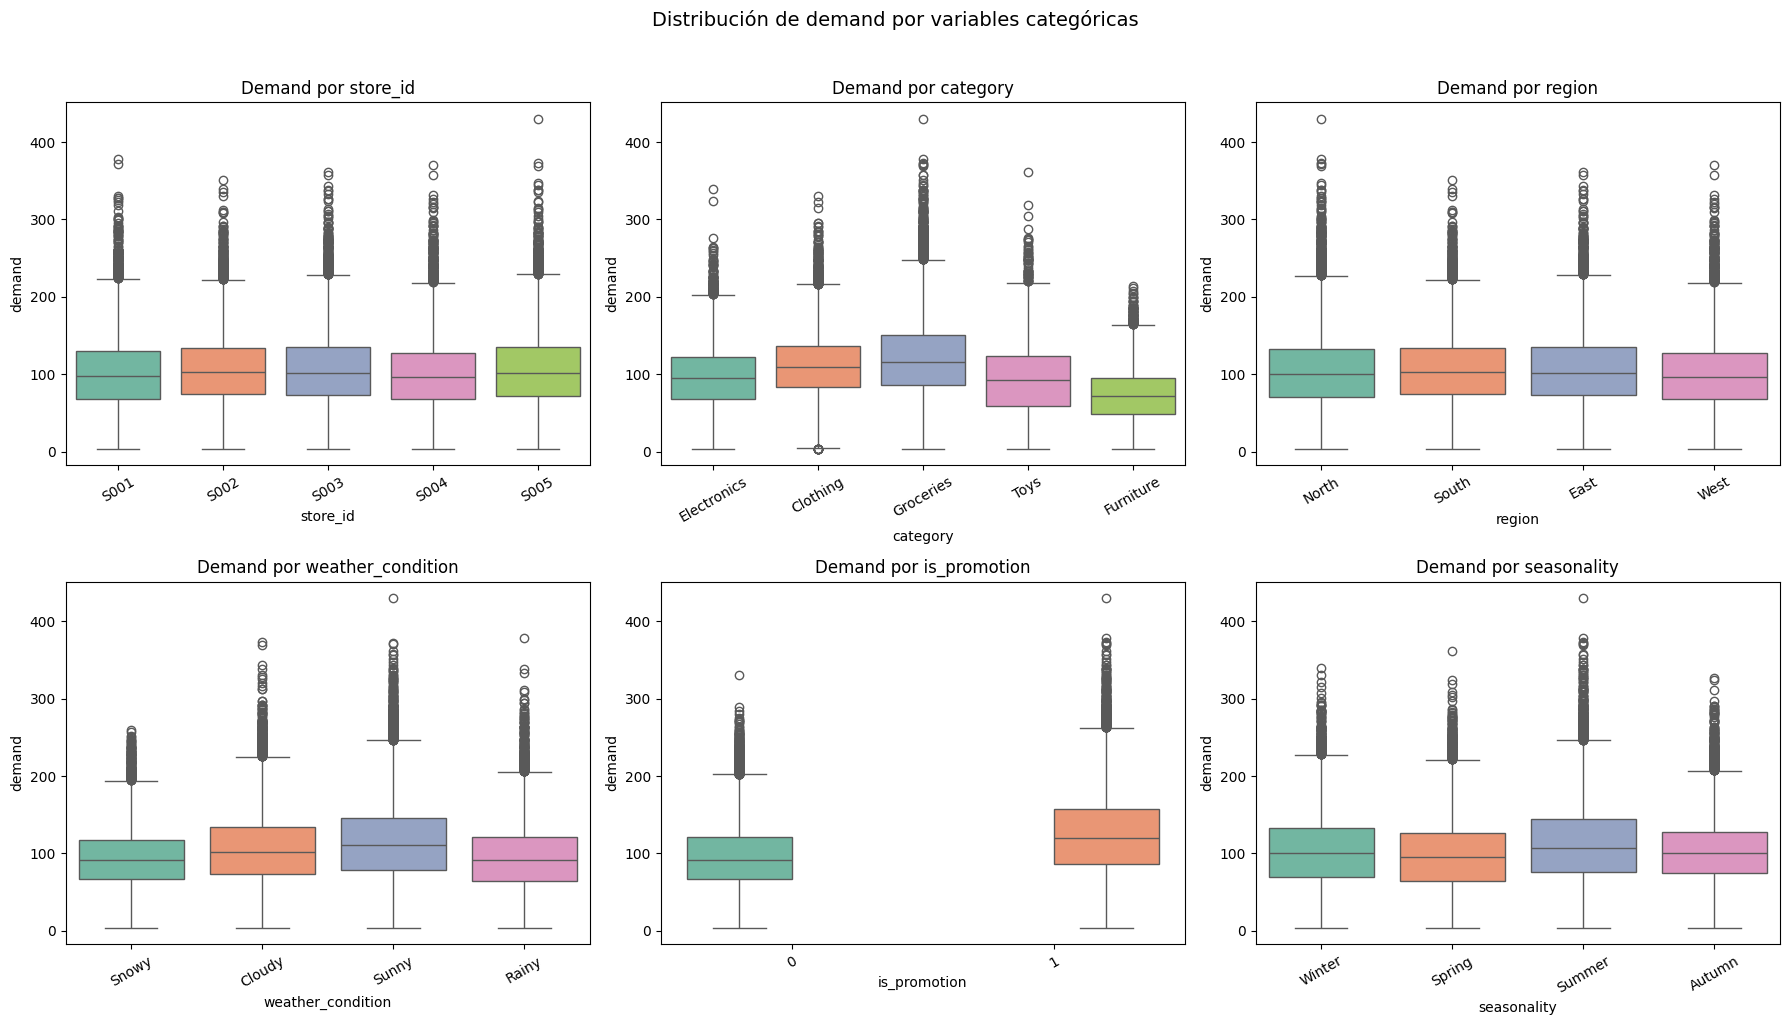

In [ ]:
# Crea o actualiza la variable 'predictores_cat' para usarla en pasos posteriores; puedes cambiar el valor de la derecha, pero revisa que no rompa celdas siguientes.
predictores_cat = [c for c in df_cat.columns if c not in ['day_of_week', 'date', 'product_id']]

# Crea el espacio de gráficos y sus ejes; puedes cambiar figsize para hacerlos más grandes o pequeños, y la cantidad de filas/columnas si ajustas axes.
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Recorre elementos para aplicar la misma acción a cada valor, producto o gráfico; puedes cambiar la fuente del recorrido si entiendes la estructura.
for ax, col in zip(axes.flatten(), predictores_cat):
    # Crea un boxplot para ver mediana, dispersión y posibles outliers; puedes cambiar x/y, data o color para analizar otra variable.
    sns.boxplot(
        # Crea o actualiza la variable 'data' para usarla en pasos posteriores; puedes cambiar el valor de la derecha, pero revisa que no rompa celdas siguientes.
        data=df, x=col, y='demand', ax=ax,
        # Crea o actualiza la variable 'hue' para usarla en pasos posteriores; puedes cambiar el valor de la derecha, pero revisa que no rompa celdas siguientes.
        hue=col, palette='Set2', legend=False
    # Esta línea cierra una estructura anterior; no recomiendo cambiarla porque puede romper paréntesis, listas o diccionarios.
    )
    # Coloca el título del gráfico para explicar qué se está mostrando; puedes cambiar el texto o fontsize sin afectar los datos.
    ax.set_title(f'Demand por {col}')
    # Ajusta apariencia de los ticks del eje; puedes cambiar rotation para leer mejor categorías largas.
    ax.tick_params(axis='x', rotation=30)


plt.suptitle('Distribución de demand por variables categóricas', fontsize=14, y=1.02)

plt.tight_layout()

plt.show()

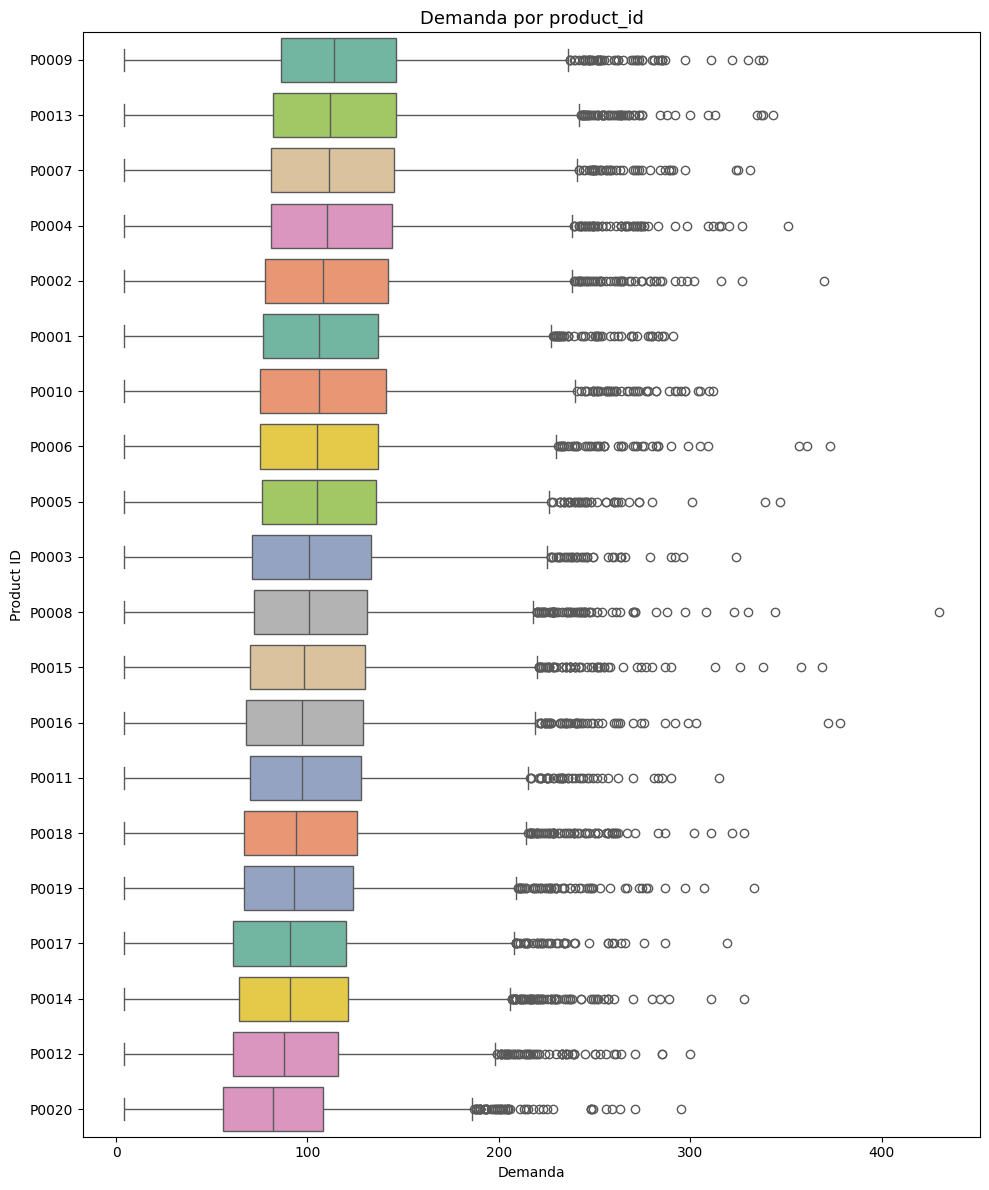

In [ ]:
# Crea el espacio de gráficos y sus ejes; puedes cambiar figsize para hacerlos más grandes o pequeños, y la cantidad de filas/columnas si ajustas axes.
fig, ax = plt.subplots(figsize=(10, 12))
# Crea un boxplot para ver mediana, dispersión y posibles outliers; puedes cambiar x/y, data o color para analizar otra variable.
sns.boxplot(
    # Crea o actualiza la variable 'data' para usarla en pasos posteriores; puedes cambiar el valor de la derecha, pero revisa que no rompa celdas siguientes.
    data=df, x='demand', y='product_id', ax=ax,
    # Crea o actualiza la variable 'hue' para usarla en pasos posteriores; puedes cambiar el valor de la derecha, pero revisa que no rompa celdas siguientes.
    hue='product_id', palette='Set2', legend=False,
    # Agrupa datos por una columna para resumir demanda, precio u otra métrica; puedes cambiar la columna de groupby para otra comparación.
    order=df.groupby('product_id')['demand'].median().sort_values(ascending=False).index
# Esta línea cierra una estructura anterior; no recomiendo cambiarla porque puede romper paréntesis, listas o diccionarios.
)
# Coloca el título del gráfico para explicar qué se está mostrando; puedes cambiar el texto o fontsize sin afectar los datos.
ax.set_title('Demanda por product_id', fontsize=13)
# Define la etiqueta del eje X; puedes cambiar el texto para que la exposición sea más clara, sin afectar los cálculos.
ax.set_xlabel('Demanda')
# Define la etiqueta del eje Y; puedes cambiar el texto para explicar mejor la variable, sin afectar los cálculos.
ax.set_ylabel('Product ID')

plt.tight_layout()

plt.show()

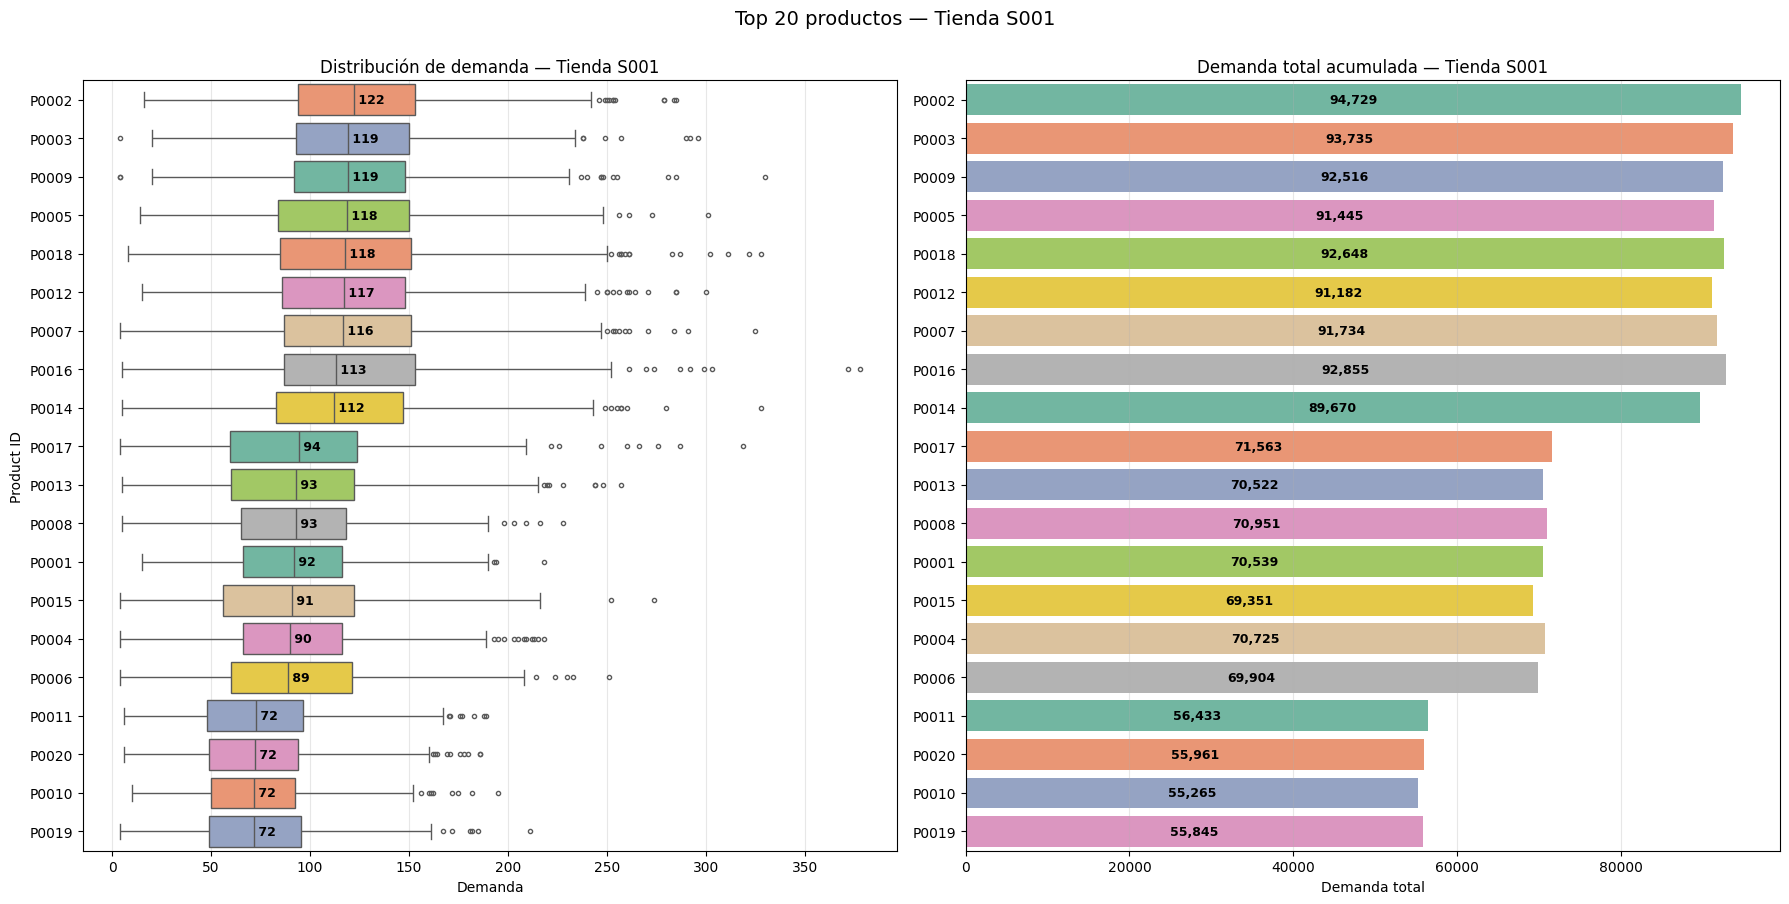

In [ ]:
# Define la tienda que se analizará en este bloque; puedes cambiar 'S001', 'S002', etc., y el gráfico mostrará otra tienda.
store = 'S001'
# Filtra el DataFrame para quedarse solo con la tienda elegida; cambia store arriba, no aquí, para evitar errores.
df_store = df[df['store_id'] == store]

# Agrupa datos por una columna para resumir demanda, precio u otra métrica; puedes cambiar la columna de groupby para otra comparación.
top20 = (df_store.groupby('product_id')['demand']
         # Calcula la mediana, un valor central robusto ante outliers; puedes cambiar la columna si quieres otra variable.
         .median().sort_values(ascending=False).head(20).index)
# Filtra filas que pertenecen a una lista de productos seleccionados; cambia la lista si quieres incluir otros productos.
df_top = df_store[df_store['product_id'].isin(top20)]

# Crea el espacio de gráficos y sus ejes; puedes cambiar figsize para hacerlos más grandes o pequeños, y la cantidad de filas/columnas si ajustas axes.
fig, axes = plt.subplots(1, 2, figsize=(18, 9))

# Crea un boxplot para ver mediana, dispersión y posibles outliers; puedes cambiar x/y, data o color para analizar otra variable.
sns.boxplot(data=df_top, x='demand', y='product_id',
            # Crea o actualiza la variable 'hue' para usarla en pasos posteriores; puedes cambiar el valor de la derecha, pero revisa que no rompa celdas siguientes.
            hue='product_id', palette='Set2', legend=False,
            # Crea o actualiza la variable 'order' para usarla en pasos posteriores; puedes cambiar el valor de la derecha, pero revisa que no rompa celdas siguientes.
            order=top20, ax=axes[0], fliersize=3)
# Coloca el título del gráfico para explicar qué se está mostrando; puedes cambiar el texto o fontsize sin afectar los datos.
axes[0].set_title(f'Distribución de demanda — Tienda {store}', fontsize=12)
# Define la etiqueta del eje X; puedes cambiar el texto para que la exposición sea más clara, sin afectar los cálculos.
axes[0].set_xlabel('Demanda')
# Define la etiqueta del eje Y; puedes cambiar el texto para explicar mejor la variable, sin afectar los cálculos.
axes[0].set_ylabel('Product ID')
# Agrega líneas de guía al gráfico; puedes cambiar alpha para hacerlas más suaves o fuertes.
axes[0].grid(axis='x', alpha=0.3)

# Agrupa datos por una columna para resumir demanda, precio u otra métrica; puedes cambiar la columna de groupby para otra comparación.
medians = df_top.groupby('product_id')['demand'].median().reindex(top20)
# Recorre elementos para aplicar la misma acción a cada valor, producto o gráfico; puedes cambiar la fuente del recorrido si entiendes la estructura.
for i, (prod, med) in enumerate(medians.items()):
    # Escribe etiquetas numéricas dentro del gráfico; puedes cambiar formato, fontsize o color para presentación.
    axes[0].text(med, i, f' {med:.0f}',
                 # Crea o actualiza la variable 'va' para usarla en pasos posteriores; puedes cambiar el valor de la derecha, pero revisa que no rompa celdas siguientes.
                 va='center', ha='left',
                 # Crea o actualiza la variable 'fontsize' para usarla en pasos posteriores; puedes cambiar el valor de la derecha, pero revisa que no rompa celdas siguientes.
                 fontsize=9, fontweight='bold', color='black')

# Agrupa datos por una columna para resumir demanda, precio u otra métrica; puedes cambiar la columna de groupby para otra comparación.
total_demand = df_top.groupby('product_id')['demand'].sum().reindex(top20)
# Crea un gráfico de barras para comparar valores por producto, tienda o categoría; puedes cambiar x/y, palette o ax para otra comparación.
sns.barplot(x=total_demand.values, y=total_demand.index,
            # Crea o actualiza la variable 'hue' para usarla en pasos posteriores; puedes cambiar el valor de la derecha, pero revisa que no rompa celdas siguientes.
            hue=total_demand.index, palette='Set2', legend=False,
            # Crea o actualiza la variable 'ax' para usarla en pasos posteriores; puedes cambiar el valor de la derecha, pero revisa que no rompa celdas siguientes.
            ax=axes[1])
# Coloca el título del gráfico para explicar qué se está mostrando; puedes cambiar el texto o fontsize sin afectar los datos.
axes[1].set_title(f'Demanda total acumulada — Tienda {store}', fontsize=12)
# Define la etiqueta del eje X; puedes cambiar el texto para que la exposición sea más clara, sin afectar los cálculos.
axes[1].set_xlabel('Demanda total')
# Define la etiqueta del eje Y; puedes cambiar el texto para explicar mejor la variable, sin afectar los cálculos.
axes[1].set_ylabel('')
# Agrega líneas de guía al gráfico; puedes cambiar alpha para hacerlas más suaves o fuertes.
axes[1].grid(axis='x', alpha=0.3)

# Recorre elementos para aplicar la misma acción a cada valor, producto o gráfico; puedes cambiar la fuente del recorrido si entiendes la estructura.
for i, val in enumerate(total_demand.values):
    # Escribe etiquetas numéricas dentro del gráfico; puedes cambiar formato, fontsize o color para presentación.
    axes[1].text(val / 2, i, f'{val:,.0f}',
                 # Crea o actualiza la variable 'va' para usarla en pasos posteriores; puedes cambiar el valor de la derecha, pero revisa que no rompa celdas siguientes.
                 va='center', ha='center',
                 # Crea o actualiza la variable 'fontsize' para usarla en pasos posteriores; puedes cambiar el valor de la derecha, pero revisa que no rompa celdas siguientes.
                 fontsize=9, fontweight='bold', color='black')

# Ajusta el límite del eje X para dejar espacio a las barras; cambiar 1.05 aumenta o reduce margen visual.
axes[1].set_xlim(0, total_demand.max() * 1.05)


plt.suptitle(f'Top 20 productos — Tienda {store}', fontsize=14, y=1.00)

plt.tight_layout()

plt.show()

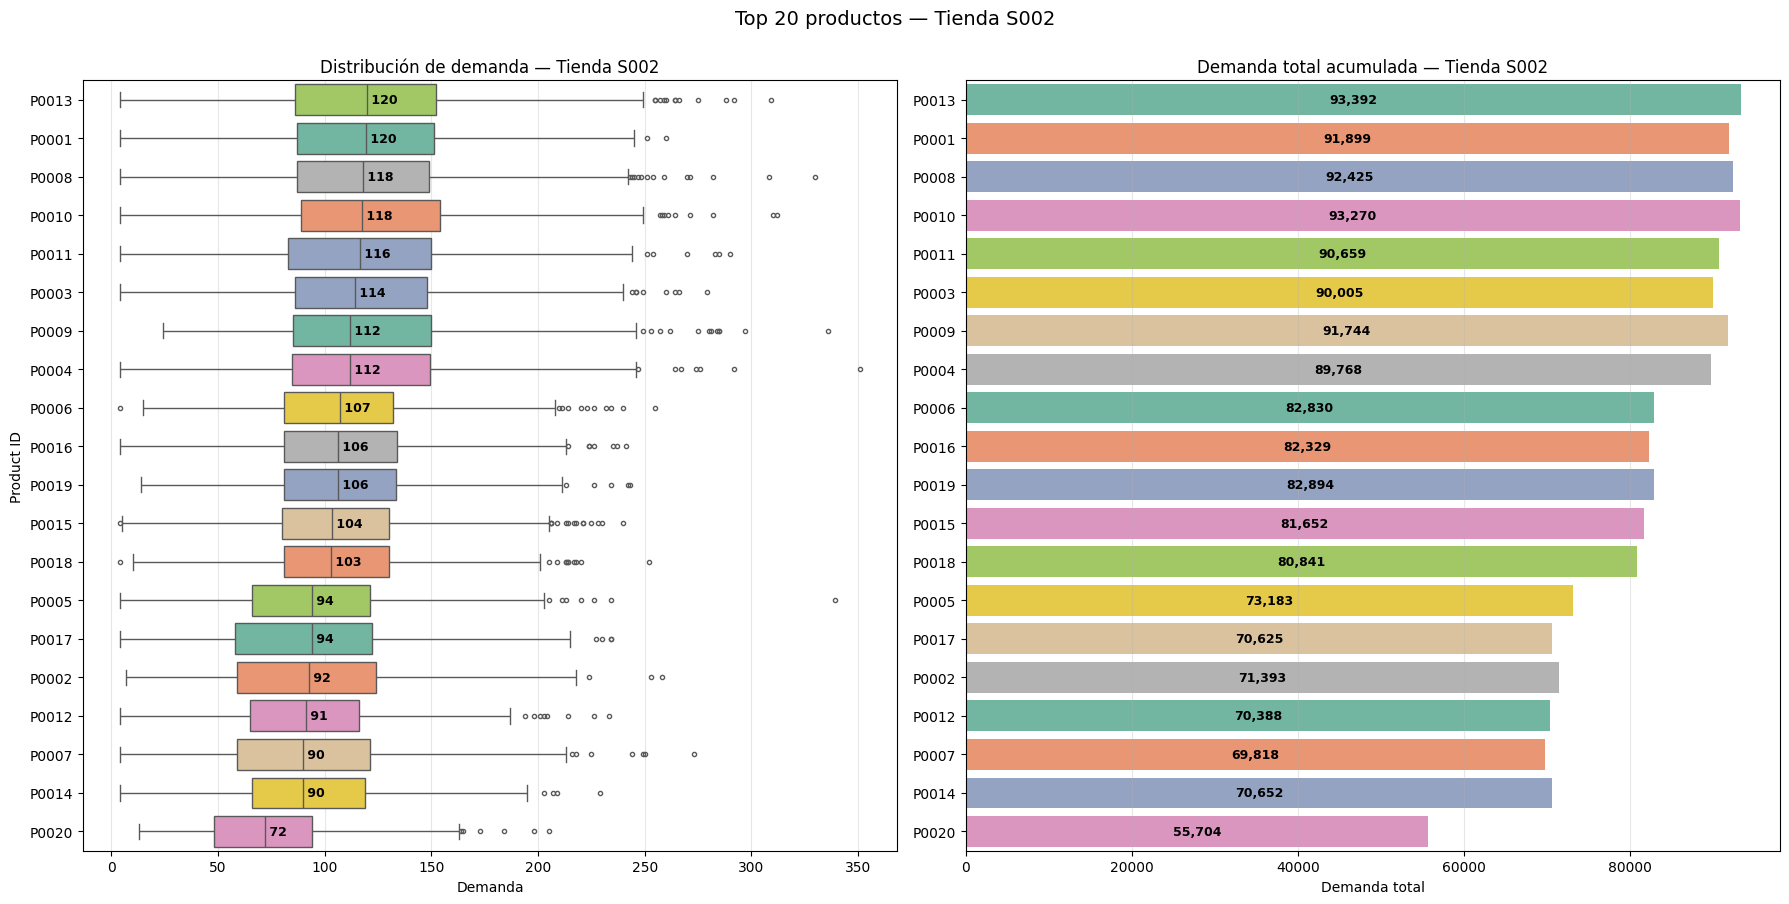

In [ ]:
# Define la tienda que se analizará en este bloque; puedes cambiar 'S001', 'S002', etc., y el gráfico mostrará otra tienda.
store = 'S002'
# Filtra el DataFrame para quedarse solo con la tienda elegida; cambia store arriba, no aquí, para evitar errores.
df_store = df[df['store_id'] == store]

# Agrupa datos por una columna para resumir demanda, precio u otra métrica; puedes cambiar la columna de groupby para otra comparación.
top20 = (df_store.groupby('product_id')['demand']
         # Calcula la mediana, un valor central robusto ante outliers; puedes cambiar la columna si quieres otra variable.
         .median().sort_values(ascending=False).head(20).index)
# Filtra filas que pertenecen a una lista de productos seleccionados; cambia la lista si quieres incluir otros productos.
df_top = df_store[df_store['product_id'].isin(top20)]

# Crea el espacio de gráficos y sus ejes; puedes cambiar figsize para hacerlos más grandes o pequeños, y la cantidad de filas/columnas si ajustas axes.
fig, axes = plt.subplots(1, 2, figsize=(18, 9))

# Crea un boxplot para ver mediana, dispersión y posibles outliers; puedes cambiar x/y, data o color para analizar otra variable.
sns.boxplot(data=df_top, x='demand', y='product_id',
            # Crea o actualiza la variable 'hue' para usarla en pasos posteriores; puedes cambiar el valor de la derecha, pero revisa que no rompa celdas siguientes.
            hue='product_id', palette='Set2', legend=False,
            # Crea o actualiza la variable 'order' para usarla en pasos posteriores; puedes cambiar el valor de la derecha, pero revisa que no rompa celdas siguientes.
            order=top20, ax=axes[0], fliersize=3)
# Coloca el título del gráfico para explicar qué se está mostrando; puedes cambiar el texto o fontsize sin afectar los datos.
axes[0].set_title(f'Distribución de demanda — Tienda {store}', fontsize=12)
# Define la etiqueta del eje X; puedes cambiar el texto para que la exposición sea más clara, sin afectar los cálculos.
axes[0].set_xlabel('Demanda')
# Define la etiqueta del eje Y; puedes cambiar el texto para explicar mejor la variable, sin afectar los cálculos.
axes[0].set_ylabel('Product ID')
# Agrega líneas de guía al gráfico; puedes cambiar alpha para hacerlas más suaves o fuertes.
axes[0].grid(axis='x', alpha=0.3)

# Agrupa datos por una columna para resumir demanda, precio u otra métrica; puedes cambiar la columna de groupby para otra comparación.
medians = df_top.groupby('product_id')['demand'].median().reindex(top20)
# Recorre elementos para aplicar la misma acción a cada valor, producto o gráfico; puedes cambiar la fuente del recorrido si entiendes la estructura.
for i, (prod, med) in enumerate(medians.items()):
    # Escribe etiquetas numéricas dentro del gráfico; puedes cambiar formato, fontsize o color para presentación.
    axes[0].text(med, i, f' {med:.0f}',
                 # Crea o actualiza la variable 'va' para usarla en pasos posteriores; puedes cambiar el valor de la derecha, pero revisa que no rompa celdas siguientes.
                 va='center', ha='left',
                 # Crea o actualiza la variable 'fontsize' para usarla en pasos posteriores; puedes cambiar el valor de la derecha, pero revisa que no rompa celdas siguientes.
                 fontsize=9, fontweight='bold', color='black')

# Agrupa datos por una columna para resumir demanda, precio u otra métrica; puedes cambiar la columna de groupby para otra comparación.
total_demand = df_top.groupby('product_id')['demand'].sum().reindex(top20)
# Crea un gráfico de barras para comparar valores por producto, tienda o categoría; puedes cambiar x/y, palette o ax para otra comparación.
sns.barplot(x=total_demand.values, y=total_demand.index,
            # Crea o actualiza la variable 'hue' para usarla en pasos posteriores; puedes cambiar el valor de la derecha, pero revisa que no rompa celdas siguientes.
            hue=total_demand.index, palette='Set2', legend=False,
            # Crea o actualiza la variable 'ax' para usarla en pasos posteriores; puedes cambiar el valor de la derecha, pero revisa que no rompa celdas siguientes.
            ax=axes[1])
# Coloca el título del gráfico para explicar qué se está mostrando; puedes cambiar el texto o fontsize sin afectar los datos.
axes[1].set_title(f'Demanda total acumulada — Tienda {store}', fontsize=12)
# Define la etiqueta del eje X; puedes cambiar el texto para que la exposición sea más clara, sin afectar los cálculos.
axes[1].set_xlabel('Demanda total')
# Define la etiqueta del eje Y; puedes cambiar el texto para explicar mejor la variable, sin afectar los cálculos.
axes[1].set_ylabel('')
# Agrega líneas de guía al gráfico; puedes cambiar alpha para hacerlas más suaves o fuertes.
axes[1].grid(axis='x', alpha=0.3)

# Recorre elementos para aplicar la misma acción a cada valor, producto o gráfico; puedes cambiar la fuente del recorrido si entiendes la estructura.
for i, val in enumerate(total_demand.values):
    # Escribe etiquetas numéricas dentro del gráfico; puedes cambiar formato, fontsize o color para presentación.
    axes[1].text(val / 2, i, f'{val:,.0f}',
                 # Crea o actualiza la variable 'va' para usarla en pasos posteriores; puedes cambiar el valor de la derecha, pero revisa que no rompa celdas siguientes.
                 va='center', ha='center',
                 # Crea o actualiza la variable 'fontsize' para usarla en pasos posteriores; puedes cambiar el valor de la derecha, pero revisa que no rompa celdas siguientes.
                 fontsize=9, fontweight='bold', color='black')

# Ajusta el límite del eje X para dejar espacio a las barras; cambiar 1.05 aumenta o reduce margen visual.
axes[1].set_xlim(0, total_demand.max() * 1.05)

# Agrega un título general a varios gráficos; puedes cambiar el texto, fontsize o y para moverlo visualmente.
plt.suptitle(f'Top 20 productos — Tienda {store}', fontsize=14, y=1.00)

plt.tight_layout()

plt.show()

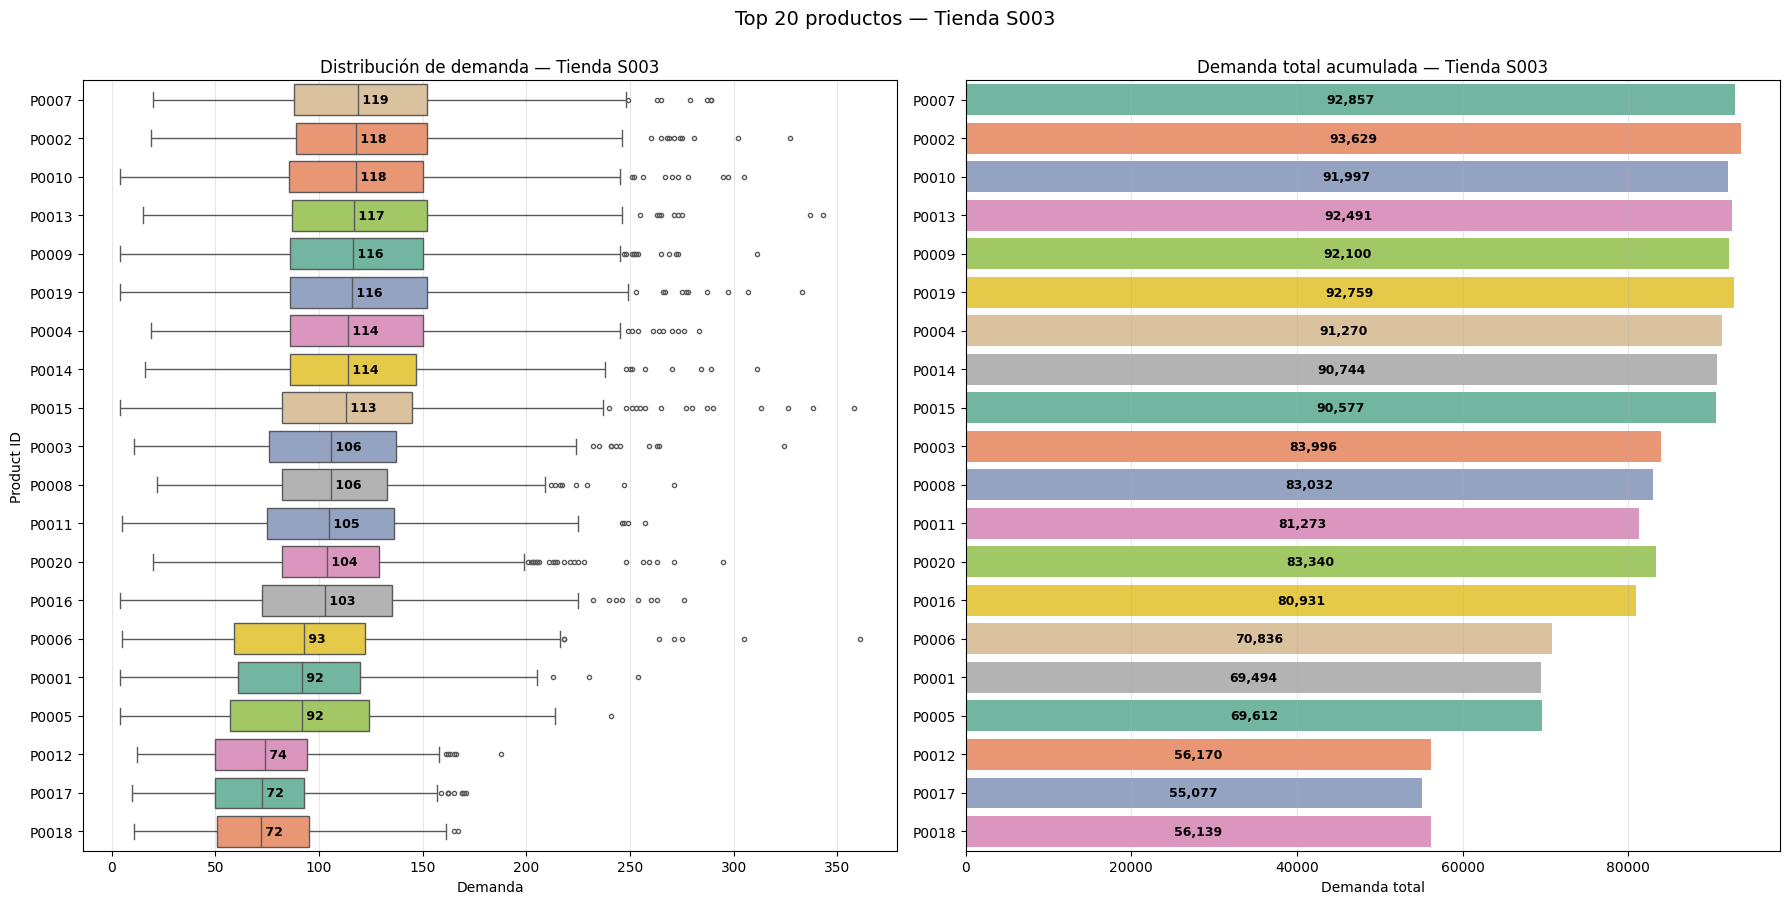

In [ ]:
# Define la tienda que se analizará en este bloque; puedes cambiar 'S001', 'S002', etc., y el gráfico mostrará otra tienda.
store = 'S003'
# Filtra el DataFrame para quedarse solo con la tienda elegida; cambia store arriba, no aquí, para evitar errores.
df_store = df[df['store_id'] == store]

# Agrupa datos por una columna para resumir demanda, precio u otra métrica; puedes cambiar la columna de groupby para otra comparación.
top20 = (df_store.groupby('product_id')['demand']
         # Calcula la mediana, un valor central robusto ante outliers; puedes cambiar la columna si quieres otra variable.
         .median().sort_values(ascending=False).head(20).index)
# Filtra filas que pertenecen a una lista de productos seleccionados; cambia la lista si quieres incluir otros productos.
df_top = df_store[df_store['product_id'].isin(top20)]

# Crea el espacio de gráficos y sus ejes; puedes cambiar figsize para hacerlos más grandes o pequeños, y la cantidad de filas/columnas si ajustas axes.
fig, axes = plt.subplots(1, 2, figsize=(18, 9))

# Crea un boxplot para ver mediana, dispersión y posibles outliers; puedes cambiar x/y, data o color para analizar otra variable.
sns.boxplot(data=df_top, x='demand', y='product_id',
            # Crea o actualiza la variable 'hue' para usarla en pasos posteriores; puedes cambiar el valor de la derecha, pero revisa que no rompa celdas siguientes.
            hue='product_id', palette='Set2', legend=False,
            # Crea o actualiza la variable 'order' para usarla en pasos posteriores; puedes cambiar el valor de la derecha, pero revisa que no rompa celdas siguientes.
            order=top20, ax=axes[0], fliersize=3)
# Coloca el título del gráfico para explicar qué se está mostrando; puedes cambiar el texto o fontsize sin afectar los datos.
axes[0].set_title(f'Distribución de demanda — Tienda {store}', fontsize=12)
# Define la etiqueta del eje X; puedes cambiar el texto para que la exposición sea más clara, sin afectar los cálculos.
axes[0].set_xlabel('Demanda')
# Define la etiqueta del eje Y; puedes cambiar el texto para explicar mejor la variable, sin afectar los cálculos.
axes[0].set_ylabel('Product ID')
# Agrega líneas de guía al gráfico; puedes cambiar alpha para hacerlas más suaves o fuertes.
axes[0].grid(axis='x', alpha=0.3)

# Agrupa datos por una columna para resumir demanda, precio u otra métrica; puedes cambiar la columna de groupby para otra comparación.
medians = df_top.groupby('product_id')['demand'].median().reindex(top20)
# Recorre elementos para aplicar la misma acción a cada valor, producto o gráfico; puedes cambiar la fuente del recorrido si entiendes la estructura.
for i, (prod, med) in enumerate(medians.items()):
    # Escribe etiquetas numéricas dentro del gráfico; puedes cambiar formato, fontsize o color para presentación.
    axes[0].text(med, i, f' {med:.0f}',
                 # Crea o actualiza la variable 'va' para usarla en pasos posteriores; puedes cambiar el valor de la derecha, pero revisa que no rompa celdas siguientes.
                 va='center', ha='left',
                 # Crea o actualiza la variable 'fontsize' para usarla en pasos posteriores; puedes cambiar el valor de la derecha, pero revisa que no rompa celdas siguientes.
                 fontsize=9, fontweight='bold', color='black')

# Agrupa datos por una columna para resumir demanda, precio u otra métrica; puedes cambiar la columna de groupby para otra comparación.
total_demand = df_top.groupby('product_id')['demand'].sum().reindex(top20)
# Crea un gráfico de barras para comparar valores por producto, tienda o categoría; puedes cambiar x/y, palette o ax para otra comparación.
sns.barplot(x=total_demand.values, y=total_demand.index,
            # Crea o actualiza la variable 'hue' para usarla en pasos posteriores; puedes cambiar el valor de la derecha, pero revisa que no rompa celdas siguientes.
            hue=total_demand.index, palette='Set2', legend=False,
            # Crea o actualiza la variable 'ax' para usarla en pasos posteriores; puedes cambiar el valor de la derecha, pero revisa que no rompa celdas siguientes.
            ax=axes[1])
# Coloca el título del gráfico para explicar qué se está mostrando; puedes cambiar el texto o fontsize sin afectar los datos.
axes[1].set_title(f'Demanda total acumulada — Tienda {store}', fontsize=12)
# Define la etiqueta del eje X; puedes cambiar el texto para que la exposición sea más clara, sin afectar los cálculos.
axes[1].set_xlabel('Demanda total')
# Define la etiqueta del eje Y; puedes cambiar el texto para explicar mejor la variable, sin afectar los cálculos.
axes[1].set_ylabel('')
# Agrega líneas de guía al gráfico; puedes cambiar alpha para hacerlas más suaves o fuertes.
axes[1].grid(axis='x', alpha=0.3)

# Recorre elementos para aplicar la misma acción a cada valor, producto o gráfico; puedes cambiar la fuente del recorrido si entiendes la estructura.
for i, val in enumerate(total_demand.values):
    # Escribe etiquetas numéricas dentro del gráfico; puedes cambiar formato, fontsize o color para presentación.
    axes[1].text(val / 2, i, f'{val:,.0f}',
                 # Crea o actualiza la variable 'va' para usarla en pasos posteriores; puedes cambiar el valor de la derecha, pero revisa que no rompa celdas siguientes.
                 va='center', ha='center',
                 # Crea o actualiza la variable 'fontsize' para usarla en pasos posteriores; puedes cambiar el valor de la derecha, pero revisa que no rompa celdas siguientes.
                 fontsize=9, fontweight='bold', color='black')

# Ajusta el límite del eje X para dejar espacio a las barras; cambiar 1.05 aumenta o reduce margen visual.
axes[1].set_xlim(0, total_demand.max() * 1.05)

# Agrega un título general a varios gráficos; puedes cambiar el texto, fontsize o y para moverlo visualmente.
plt.suptitle(f'Top 20 productos — Tienda {store}', fontsize=14, y=1.00)

plt.tight_layout()

plt.show()

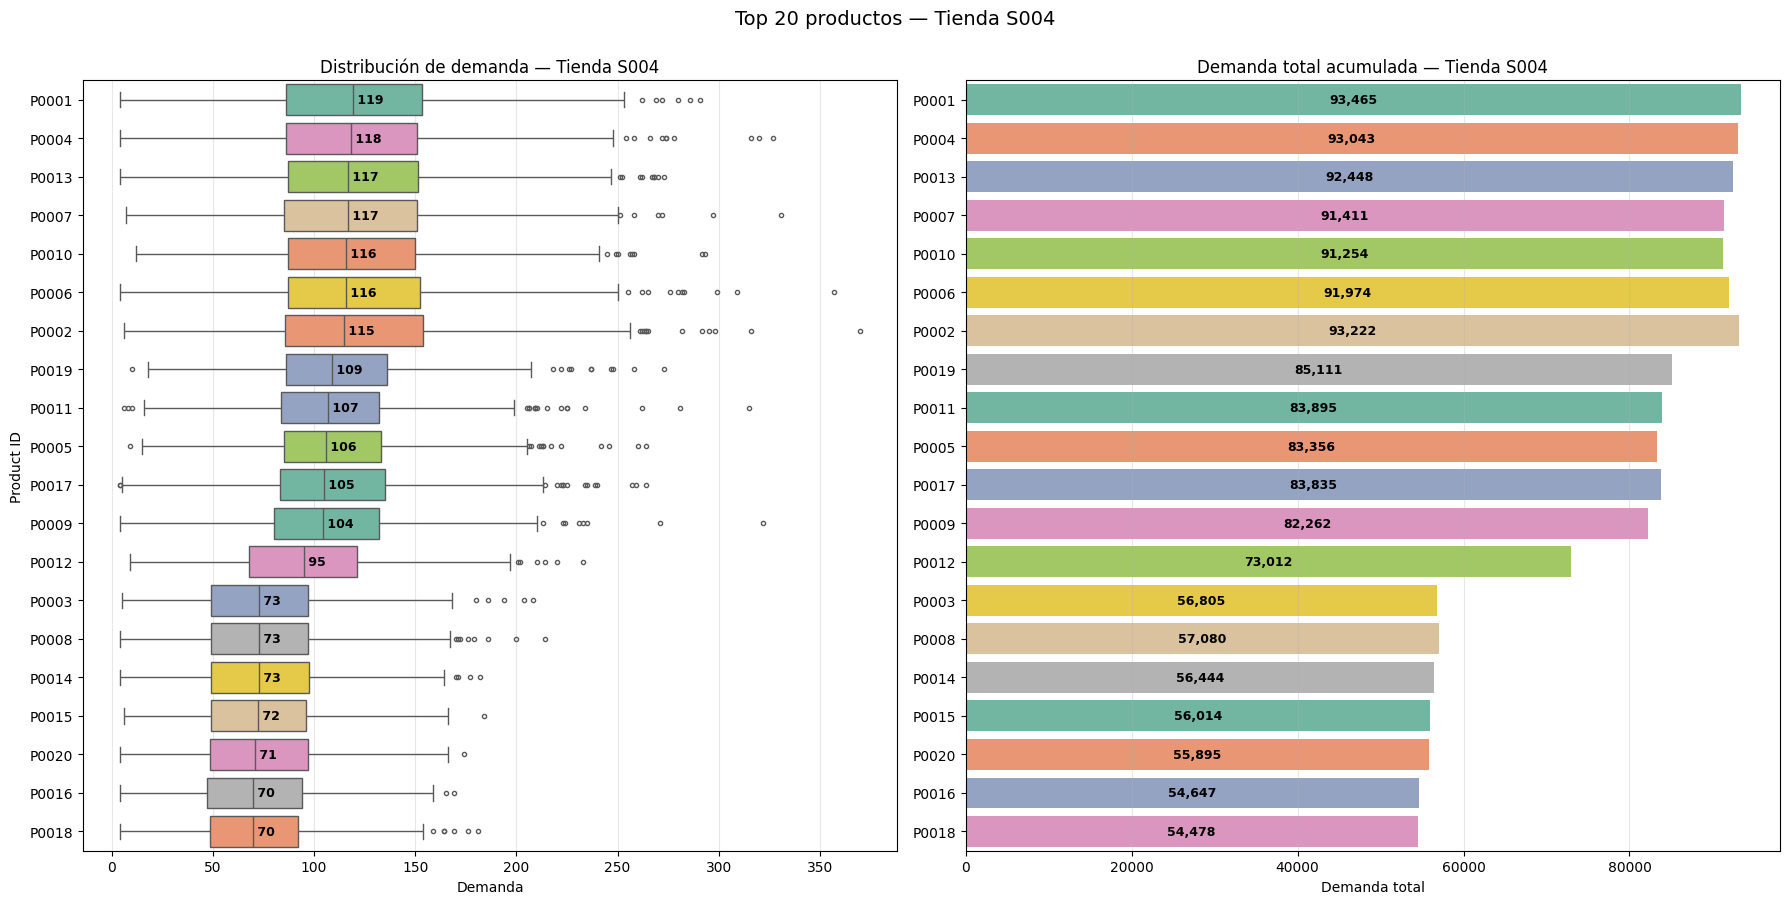

In [ ]:
# Define la tienda que se analizará en este bloque; puedes cambiar 'S001', 'S002', etc., y el gráfico mostrará otra tienda.
store = 'S004'
# Filtra el DataFrame para quedarse solo con la tienda elegida; cambia store arriba, no aquí, para evitar errores.
df_store = df[df['store_id'] == store]

# Agrupa datos por una columna para resumir demanda, precio u otra métrica; puedes cambiar la columna de groupby para otra comparación.
top20 = (df_store.groupby('product_id')['demand']
         # Calcula la mediana, un valor central robusto ante outliers; puedes cambiar la columna si quieres otra variable.
         .median().sort_values(ascending=False).head(20).index)
# Filtra filas que pertenecen a una lista de productos seleccionados; cambia la lista si quieres incluir otros productos.
df_top = df_store[df_store['product_id'].isin(top20)]

# Crea el espacio de gráficos y sus ejes; puedes cambiar figsize para hacerlos más grandes o pequeños, y la cantidad de filas/columnas si ajustas axes.
fig, axes = plt.subplots(1, 2, figsize=(18, 9))

# Crea un boxplot para ver mediana, dispersión y posibles outliers; puedes cambiar x/y, data o color para analizar otra variable.
sns.boxplot(data=df_top, x='demand', y='product_id',
            # Crea o actualiza la variable 'hue' para usarla en pasos posteriores; puedes cambiar el valor de la derecha, pero revisa que no rompa celdas siguientes.
            hue='product_id', palette='Set2', legend=False,
            # Crea o actualiza la variable 'order' para usarla en pasos posteriores; puedes cambiar el valor de la derecha, pero revisa que no rompa celdas siguientes.
            order=top20, ax=axes[0], fliersize=3)
# Coloca el título del gráfico para explicar qué se está mostrando; puedes cambiar el texto o fontsize sin afectar los datos.
axes[0].set_title(f'Distribución de demanda — Tienda {store}', fontsize=12)
# Define la etiqueta del eje X; puedes cambiar el texto para que la exposición sea más clara, sin afectar los cálculos.
axes[0].set_xlabel('Demanda')
# Define la etiqueta del eje Y; puedes cambiar el texto para explicar mejor la variable, sin afectar los cálculos.
axes[0].set_ylabel('Product ID')
# Agrega líneas de guía al gráfico; puedes cambiar alpha para hacerlas más suaves o fuertes.
axes[0].grid(axis='x', alpha=0.3)

# Agrupa datos por una columna para resumir demanda, precio u otra métrica; puedes cambiar la columna de groupby para otra comparación.
medians = df_top.groupby('product_id')['demand'].median().reindex(top20)
# Recorre elementos para aplicar la misma acción a cada valor, producto o gráfico; puedes cambiar la fuente del recorrido si entiendes la estructura.
for i, (prod, med) in enumerate(medians.items()):
    # Escribe etiquetas numéricas dentro del gráfico; puedes cambiar formato, fontsize o color para presentación.
    axes[0].text(med, i, f' {med:.0f}',
                 # Crea o actualiza la variable 'va' para usarla en pasos posteriores; puedes cambiar el valor de la derecha, pero revisa que no rompa celdas siguientes.
                 va='center', ha='left',
                 # Crea o actualiza la variable 'fontsize' para usarla en pasos posteriores; puedes cambiar el valor de la derecha, pero revisa que no rompa celdas siguientes.
                 fontsize=9, fontweight='bold', color='black')

# Agrupa datos por una columna para resumir demanda, precio u otra métrica; puedes cambiar la columna de groupby para otra comparación.
total_demand = df_top.groupby('product_id')['demand'].sum().reindex(top20)
# Crea un gráfico de barras para comparar valores por producto, tienda o categoría; puedes cambiar x/y, palette o ax para otra comparación.
sns.barplot(x=total_demand.values, y=total_demand.index,
            # Crea o actualiza la variable 'hue' para usarla en pasos posteriores; puedes cambiar el valor de la derecha, pero revisa que no rompa celdas siguientes.
            hue=total_demand.index, palette='Set2', legend=False,
            # Crea o actualiza la variable 'ax' para usarla en pasos posteriores; puedes cambiar el valor de la derecha, pero revisa que no rompa celdas siguientes.
            ax=axes[1])
# Coloca el título del gráfico para explicar qué se está mostrando; puedes cambiar el texto o fontsize sin afectar los datos.
axes[1].set_title(f'Demanda total acumulada — Tienda {store}', fontsize=12)
# Define la etiqueta del eje X; puedes cambiar el texto para que la exposición sea más clara, sin afectar los cálculos.
axes[1].set_xlabel('Demanda total')
# Define la etiqueta del eje Y; puedes cambiar el texto para explicar mejor la variable, sin afectar los cálculos.
axes[1].set_ylabel('')
# Agrega líneas de guía al gráfico; puedes cambiar alpha para hacerlas más suaves o fuertes.
axes[1].grid(axis='x', alpha=0.3)

# Recorre elementos para aplicar la misma acción a cada valor, producto o gráfico; puedes cambiar la fuente del recorrido si entiendes la estructura.
for i, val in enumerate(total_demand.values):
    # Escribe etiquetas numéricas dentro del gráfico; puedes cambiar formato, fontsize o color para presentación.
    axes[1].text(val / 2, i, f'{val:,.0f}',
                 # Crea o actualiza la variable 'va' para usarla en pasos posteriores; puedes cambiar el valor de la derecha, pero revisa que no rompa celdas siguientes.
                 va='center', ha='center',
                 # Crea o actualiza la variable 'fontsize' para usarla en pasos posteriores; puedes cambiar el valor de la derecha, pero revisa que no rompa celdas siguientes.
                 fontsize=9, fontweight='bold', color='black')

# Ajusta el límite del eje X para dejar espacio a las barras; cambiar 1.05 aumenta o reduce margen visual.
axes[1].set_xlim(0, total_demand.max() * 1.05)

# Agrega un título general a varios gráficos; puedes cambiar el texto, fontsize o y para moverlo visualmente.
plt.suptitle(f'Top 20 productos — Tienda {store}', fontsize=14, y=1.00)

plt.tight_layout()

plt.show()

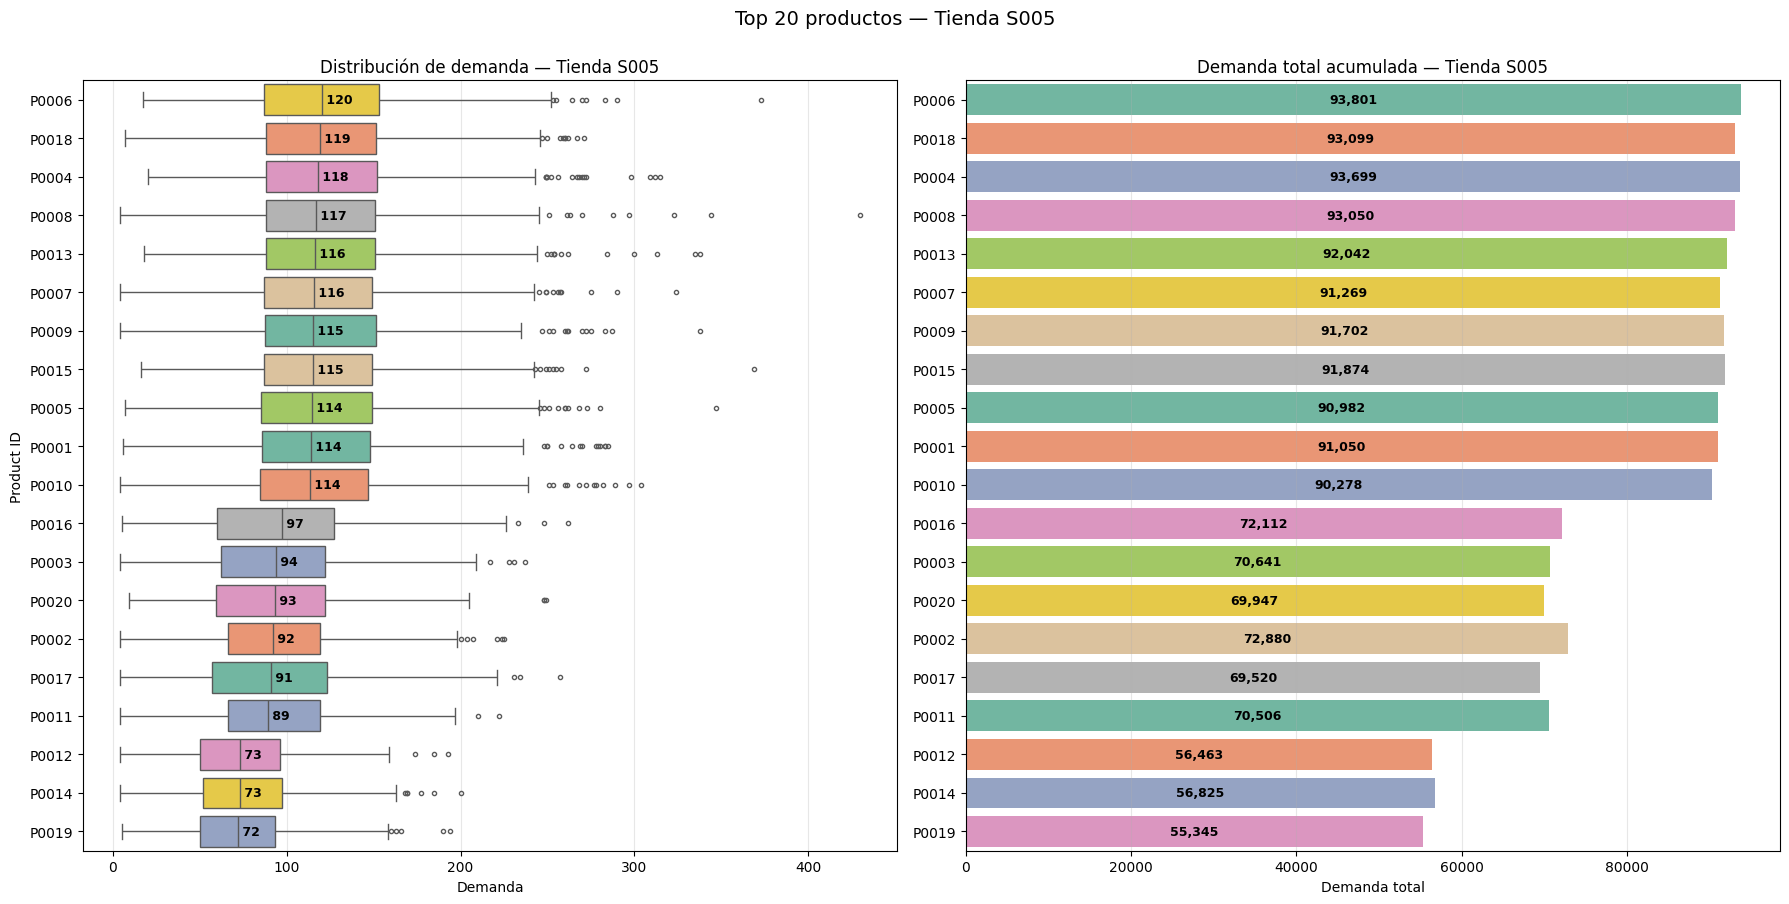

In [ ]:
# Define la tienda que se analizará en este bloque; puedes cambiar 'S001', 'S002', etc., y el gráfico mostrará otra tienda.
store = 'S005'
# Filtra el DataFrame para quedarse solo con la tienda elegida; cambia store arriba, no aquí, para evitar errores.
df_store = df[df['store_id'] == store]

# Agrupa datos por una columna para resumir demanda, precio u otra métrica; puedes cambiar la columna de groupby para otra comparación.
top20 = (df_store.groupby('product_id')['demand']
         # Calcula la mediana, un valor central robusto ante outliers; puedes cambiar la columna si quieres otra variable.
         .median().sort_values(ascending=False).head(20).index)
# Filtra filas que pertenecen a una lista de productos seleccionados; cambia la lista si quieres incluir otros productos.
df_top = df_store[df_store['product_id'].isin(top20)]

# Crea el espacio de gráficos y sus ejes; puedes cambiar figsize para hacerlos más grandes o pequeños, y la cantidad de filas/columnas si ajustas axes.
fig, axes = plt.subplots(1, 2, figsize=(18, 9))

# Crea un boxplot para ver mediana, dispersión y posibles outliers; puedes cambiar x/y, data o color para analizar otra variable.
sns.boxplot(data=df_top, x='demand', y='product_id',
            # Crea o actualiza la variable 'hue' para usarla en pasos posteriores; puedes cambiar el valor de la derecha, pero revisa que no rompa celdas siguientes.
            hue='product_id', palette='Set2', legend=False,
            # Crea o actualiza la variable 'order' para usarla en pasos posteriores; puedes cambiar el valor de la derecha, pero revisa que no rompa celdas siguientes.
            order=top20, ax=axes[0], fliersize=3)
# Coloca el título del gráfico para explicar qué se está mostrando; puedes cambiar el texto o fontsize sin afectar los datos.
axes[0].set_title(f'Distribución de demanda — Tienda {store}', fontsize=12)
# Define la etiqueta del eje X; puedes cambiar el texto para que la exposición sea más clara, sin afectar los cálculos.
axes[0].set_xlabel('Demanda')
# Define la etiqueta del eje Y; puedes cambiar el texto para explicar mejor la variable, sin afectar los cálculos.
axes[0].set_ylabel('Product ID')
# Agrega líneas de guía al gráfico; puedes cambiar alpha para hacerlas más suaves o fuertes.
axes[0].grid(axis='x', alpha=0.3)

# Agrupa datos por una columna para resumir demanda, precio u otra métrica; puedes cambiar la columna de groupby para otra comparación.
medians = df_top.groupby('product_id')['demand'].median().reindex(top20)
# Recorre elementos para aplicar la misma acción a cada valor, producto o gráfico; puedes cambiar la fuente del recorrido si entiendes la estructura.
for i, (prod, med) in enumerate(medians.items()):
    # Escribe etiquetas numéricas dentro del gráfico; puedes cambiar formato, fontsize o color para presentación.
    axes[0].text(med, i, f' {med:.0f}',
                 # Crea o actualiza la variable 'va' para usarla en pasos posteriores; puedes cambiar el valor de la derecha, pero revisa que no rompa celdas siguientes.
                 va='center', ha='left',
                 # Crea o actualiza la variable 'fontsize' para usarla en pasos posteriores; puedes cambiar el valor de la derecha, pero revisa que no rompa celdas siguientes.
                 fontsize=9, fontweight='bold', color='black')

# Agrupa datos por una columna para resumir demanda, precio u otra métrica; puedes cambiar la columna de groupby para otra comparación.
total_demand = df_top.groupby('product_id')['demand'].sum().reindex(top20)
# Crea un gráfico de barras para comparar valores por producto, tienda o categoría; puedes cambiar x/y, palette o ax para otra comparación.
sns.barplot(x=total_demand.values, y=total_demand.index,
            # Crea o actualiza la variable 'hue' para usarla en pasos posteriores; puedes cambiar el valor de la derecha, pero revisa que no rompa celdas siguientes.
            hue=total_demand.index, palette='Set2', legend=False,
            # Crea o actualiza la variable 'ax' para usarla en pasos posteriores; puedes cambiar el valor de la derecha, pero revisa que no rompa celdas siguientes.
            ax=axes[1])
# Coloca el título del gráfico para explicar qué se está mostrando; puedes cambiar el texto o fontsize sin afectar los datos.
axes[1].set_title(f'Demanda total acumulada — Tienda {store}', fontsize=12)
# Define la etiqueta del eje X; puedes cambiar el texto para que la exposición sea más clara, sin afectar los cálculos.
axes[1].set_xlabel('Demanda total')
# Define la etiqueta del eje Y; puedes cambiar el texto para explicar mejor la variable, sin afectar los cálculos.
axes[1].set_ylabel('')
# Agrega líneas de guía al gráfico; puedes cambiar alpha para hacerlas más suaves o fuertes.
axes[1].grid(axis='x', alpha=0.3)

# Recorre elementos para aplicar la misma acción a cada valor, producto o gráfico; puedes cambiar la fuente del recorrido si entiendes la estructura.
for i, val in enumerate(total_demand.values):
    # Escribe etiquetas numéricas dentro del gráfico; puedes cambiar formato, fontsize o color para presentación.
    axes[1].text(val / 2, i, f'{val:,.0f}',
                 # Crea o actualiza la variable 'va' para usarla en pasos posteriores; puedes cambiar el valor de la derecha, pero revisa que no rompa celdas siguientes.
                 va='center', ha='center',
                 # Crea o actualiza la variable 'fontsize' para usarla en pasos posteriores; puedes cambiar el valor de la derecha, pero revisa que no rompa celdas siguientes.
                 fontsize=9, fontweight='bold', color='black')

# Ajusta el límite del eje X para dejar espacio a las barras; cambiar 1.05 aumenta o reduce margen visual.
axes[1].set_xlim(0, total_demand.max() * 1.05)

# Agrega un título general a varios gráficos; puedes cambiar el texto, fontsize o y para moverlo visualmente.
plt.suptitle(f'Top 20 productos — Tienda {store}', fontsize=14, y=1.00)

plt.tight_layout()

plt.show()

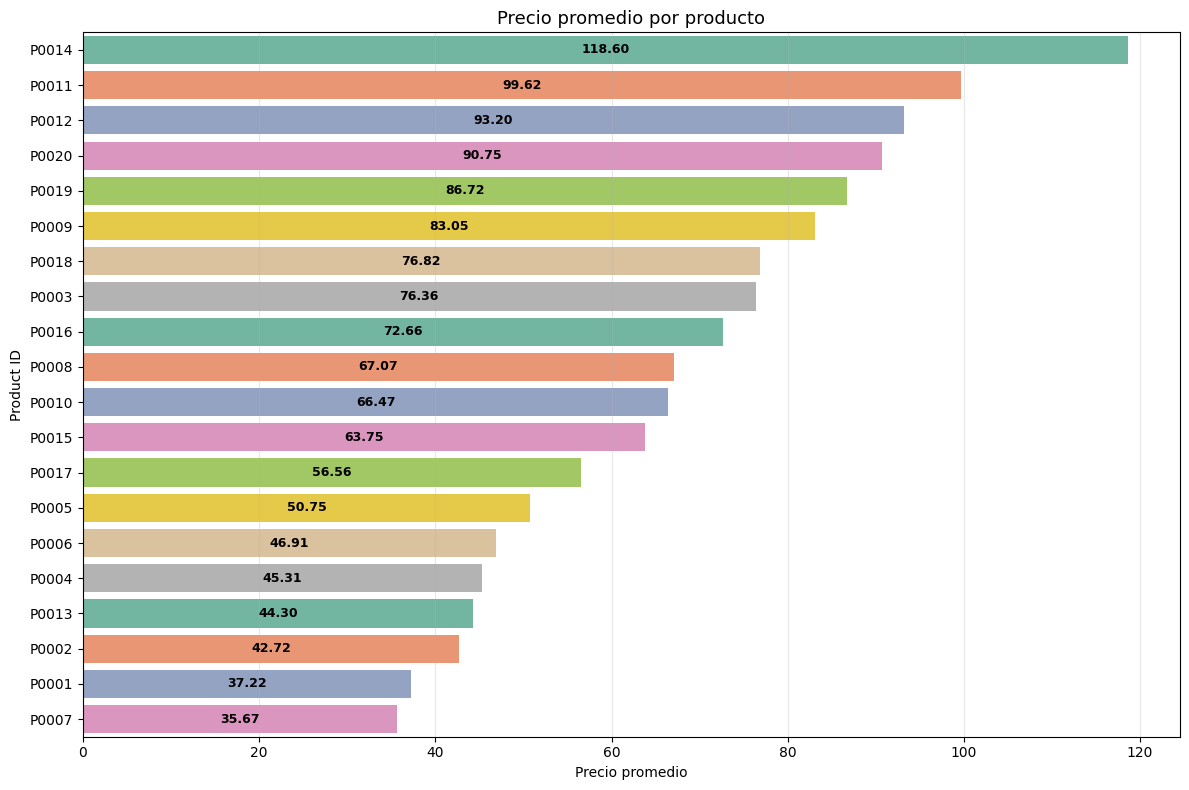

In [ ]:
# Crea el espacio de gráficos y sus ejes; puedes cambiar figsize para hacerlos más grandes o pequeños, y la cantidad de filas/columnas si ajustas axes.
fig, ax = plt.subplots(figsize=(12, 8))

# Agrupa datos por una columna para resumir demanda, precio u otra métrica; puedes cambiar la columna de groupby para otra comparación.
precio_promedio = (df.groupby('product_id')['price']
                   # Ordena los resultados para ver primero mayores o menores; puedes cambiar ascending para invertir el orden.
                   .mean().sort_values(ascending=False))

# Crea un gráfico de barras para comparar valores por producto, tienda o categoría; puedes cambiar x/y, palette o ax para otra comparación.
sns.barplot(x=precio_promedio.values, y=precio_promedio.index,
            # Crea o actualiza la variable 'hue' para usarla en pasos posteriores; puedes cambiar el valor de la derecha, pero revisa que no rompa celdas siguientes.
            hue=precio_promedio.index, palette='Set2', legend=False, ax=ax)

# Coloca el título del gráfico para explicar qué se está mostrando; puedes cambiar el texto o fontsize sin afectar los datos.
ax.set_title('Precio promedio por producto', fontsize=13)
# Define la etiqueta del eje X; puedes cambiar el texto para que la exposición sea más clara, sin afectar los cálculos.
ax.set_xlabel('Precio promedio')
# Define la etiqueta del eje Y; puedes cambiar el texto para explicar mejor la variable, sin afectar los cálculos.
ax.set_ylabel('Product ID')
# Agrega líneas de guía al gráfico; puedes cambiar alpha para hacerlas más suaves o fuertes.
ax.grid(axis='x', alpha=0.3)

# Recorre elementos para aplicar la misma acción a cada valor, producto o gráfico; puedes cambiar la fuente del recorrido si entiendes la estructura.
for i, val in enumerate(precio_promedio.values):
    # Escribe etiquetas numéricas dentro del gráfico; puedes cambiar formato, fontsize o color para presentación.
    ax.text(val / 2, i, f'{val:.2f}',
            # Crea o actualiza la variable 'va' para usarla en pasos posteriores; puedes cambiar el valor de la derecha, pero revisa que no rompa celdas siguientes.
            va='center', ha='center',
            # Crea o actualiza la variable 'fontsize' para usarla en pasos posteriores; puedes cambiar el valor de la derecha, pero revisa que no rompa celdas siguientes.
            fontsize=9, fontweight='bold', color='black')


plt.tight_layout()

plt.show()

             precio_promedio  demanda_promedio  demanda_total
category                                                     
Groceries              51.66            120.98        3677684
Clothing               71.52            112.62        1369456
Furniture             121.51             73.58        1006590
Toys                   26.91             92.61         985338
Electronics            83.17             97.48         889036


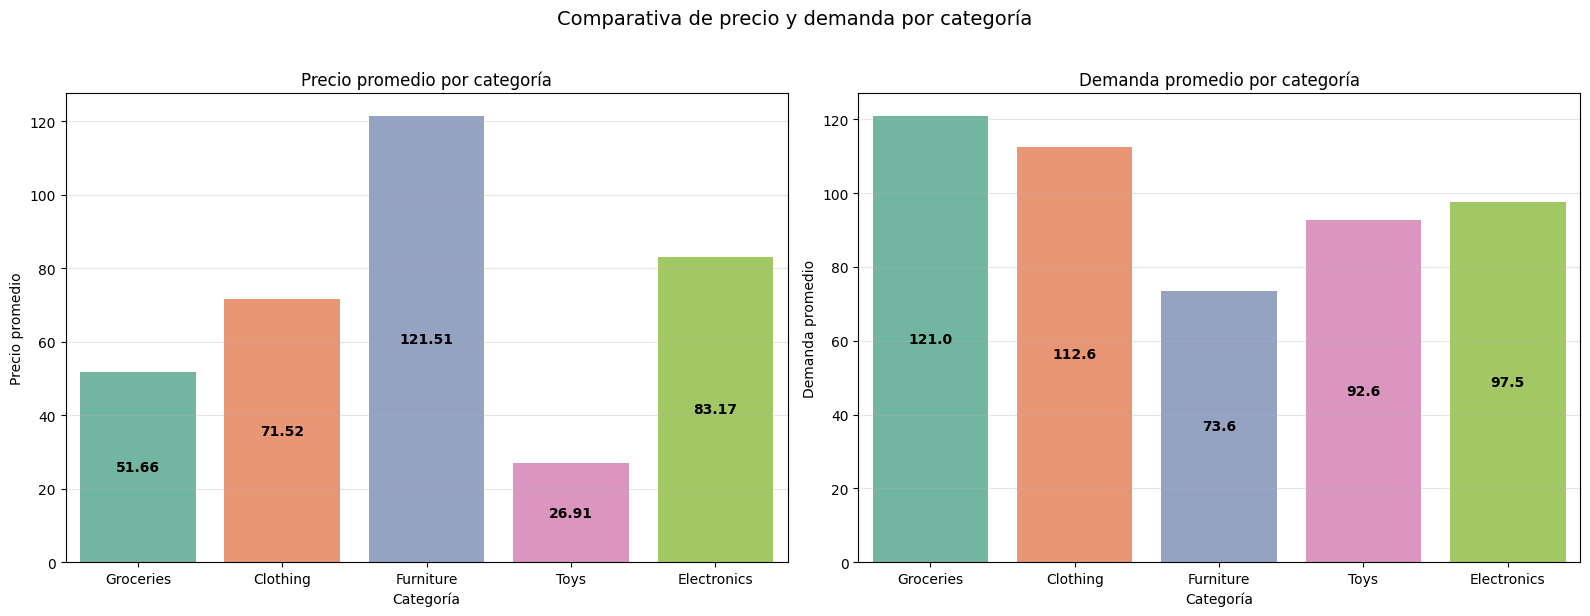

In [ ]:
# Agrupa datos por una columna para resumir demanda, precio u otra métrica; puedes cambiar la columna de groupby para otra comparación.
resumen_cat = (df.groupby('category')
               # Calcula varias métricas agrupadas al mismo tiempo; puedes cambiar mean/sum o nombres de métricas si necesitas otro resumen.
               .agg(precio_promedio=('price', 'mean'),
                    # Define una métrica de demanda promedio usando mean; puedes cambiar a median si quieres un valor menos sensible a outliers.
                    demanda_promedio=('demand', 'mean'),
                    # Define una métrica de demanda total usando sum; puedes cambiar sum por mean si buscas promedio en lugar de acumulado.
                    demanda_total=('demand', 'sum'))
               # Ordena los resultados para ver primero mayores o menores; puedes cambiar ascending para invertir el orden.
               .sort_values('demanda_total', ascending=False))

# Imprime un resultado para revisarlo en la salida; puedes cambiar el texto, pero evita cambiar variables si quieres conservar la lógica.
print(resumen_cat.round(2))

# Crea el espacio de gráficos y sus ejes; puedes cambiar figsize para hacerlos más grandes o pequeños, y la cantidad de filas/columnas si ajustas axes.
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Comentario de apoyo: esta línea ya es un comentario sobre 'Precio promedio por categoría'; puedes mejorar el texto, pero no afecta los cálculos.
# Precio promedio por categoría
# Crea un gráfico de barras para comparar valores por producto, tienda o categoría; puedes cambiar x/y, palette o ax para otra comparación.
sns.barplot(x=resumen_cat.index, y=resumen_cat['precio_promedio'],
            # Crea o actualiza la variable 'hue' para usarla en pasos posteriores; puedes cambiar el valor de la derecha, pero revisa que no rompa celdas siguientes.
            hue=resumen_cat.index, palette='Set2', legend=False, ax=axes[0])
# Coloca el título del gráfico para explicar qué se está mostrando; puedes cambiar el texto o fontsize sin afectar los datos.
axes[0].set_title('Precio promedio por categoría', fontsize=12)
# Define la etiqueta del eje X; puedes cambiar el texto para que la exposición sea más clara, sin afectar los cálculos.
axes[0].set_xlabel('Categoría')
# Define la etiqueta del eje Y; puedes cambiar el texto para explicar mejor la variable, sin afectar los cálculos.
axes[0].set_ylabel('Precio promedio')
# Agrega líneas de guía al gráfico; puedes cambiar alpha para hacerlas más suaves o fuertes.
axes[0].grid(axis='y', alpha=0.3)
# Recorre elementos para aplicar la misma acción a cada valor, producto o gráfico; puedes cambiar la fuente del recorrido si entiendes la estructura.
for i, val in enumerate(resumen_cat['precio_promedio'].values):
    # Escribe etiquetas numéricas dentro del gráfico; puedes cambiar formato, fontsize o color para presentación.
    axes[0].text(i, val / 2, f'{val:.2f}',
                 # Crea o actualiza la variable 'ha' para usarla en pasos posteriores; puedes cambiar el valor de la derecha, pero revisa que no rompa celdas siguientes.
                 ha='center', va='center',
                 # Crea o actualiza la variable 'fontsize' para usarla en pasos posteriores; puedes cambiar el valor de la derecha, pero revisa que no rompa celdas siguientes.
                 fontsize=10, fontweight='bold', color='black')

# Comentario de apoyo: esta línea ya es un comentario sobre 'Demanda promedio por categoría'; puedes mejorar el texto, pero no afecta los cálculos.
# Demanda promedio por categoría
# Crea un gráfico de barras para comparar valores por producto, tienda o categoría; puedes cambiar x/y, palette o ax para otra comparación.
sns.barplot(x=resumen_cat.index, y=resumen_cat['demanda_promedio'],
            # Crea o actualiza la variable 'hue' para usarla en pasos posteriores; puedes cambiar el valor de la derecha, pero revisa que no rompa celdas siguientes.
            hue=resumen_cat.index, palette='Set2', legend=False, ax=axes[1])
# Coloca el título del gráfico para explicar qué se está mostrando; puedes cambiar el texto o fontsize sin afectar los datos.
axes[1].set_title('Demanda promedio por categoría', fontsize=12)
# Define la etiqueta del eje X; puedes cambiar el texto para que la exposición sea más clara, sin afectar los cálculos.
axes[1].set_xlabel('Categoría')
# Define la etiqueta del eje Y; puedes cambiar el texto para explicar mejor la variable, sin afectar los cálculos.
axes[1].set_ylabel('Demanda promedio')
# Agrega líneas de guía al gráfico; puedes cambiar alpha para hacerlas más suaves o fuertes.
axes[1].grid(axis='y', alpha=0.3)
# Recorre elementos para aplicar la misma acción a cada valor, producto o gráfico; puedes cambiar la fuente del recorrido si entiendes la estructura.
for i, val in enumerate(resumen_cat['demanda_promedio'].values):
    # Escribe etiquetas numéricas dentro del gráfico; puedes cambiar formato, fontsize o color para presentación.
    axes[1].text(i, val / 2, f'{val:.1f}',
                 # Crea o actualiza la variable 'ha' para usarla en pasos posteriores; puedes cambiar el valor de la derecha, pero revisa que no rompa celdas siguientes.
                 ha='center', va='center',
                 # Crea o actualiza la variable 'fontsize' para usarla en pasos posteriores; puedes cambiar el valor de la derecha, pero revisa que no rompa celdas siguientes.
                 fontsize=10, fontweight='bold', color='black')

# Agrega un título general a varios gráficos; puedes cambiar el texto, fontsize o y para moverlo visualmente.
plt.suptitle('Comparativa de precio y demanda por categoría',
             # Crea o actualiza la variable 'fontsize' para usarla en pasos posteriores; puedes cambiar el valor de la derecha, pero revisa que no rompa celdas siguientes.
             fontsize=14, y=1.02)

plt.tight_layout()

plt.show()

Producto con MAYOR demanda total: P0009 (demanda=450,324, precio=83.05)
Producto con MAYOR precio promedio: P0014 (precio=118.60, demanda=364,335)


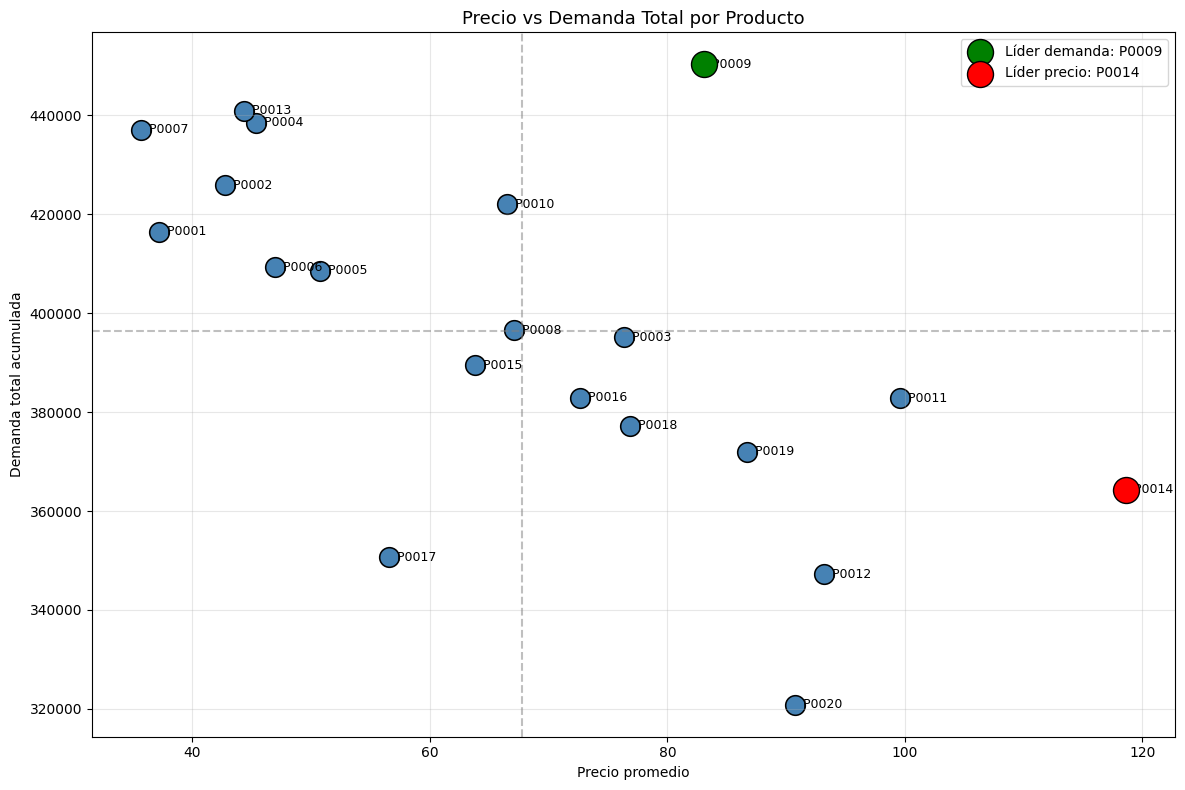

In [ ]:
# Agrupa datos por una columna para resumir demanda, precio u otra métrica; puedes cambiar la columna de groupby para otra comparación.
resumen_prod = (df.groupby('product_id')
                # Calcula varias métricas agrupadas al mismo tiempo; puedes cambiar mean/sum o nombres de métricas si necesitas otro resumen.
                .agg(precio_promedio=('price', 'mean'),
                     # Define una métrica de demanda promedio usando mean; puedes cambiar a median si quieres un valor menos sensible a outliers.
                     demanda_promedio=('demand', 'mean'),
                     # Define una métrica de demanda total usando sum; puedes cambiar sum por mean si buscas promedio en lugar de acumulado.
                     demanda_total=('demand', 'sum'))
                # Ejecuta esta línea dentro del análisis; cambia solo valores visibles como columnas, textos o colores si entiendes dónde se usan después.
                .reset_index())

# Comentario de apoyo: esta línea ya es un comentario sobre 'Identificar líderes'; puedes mejorar el texto, pero no afecta los cálculos.
# Identificar líderes
# Ubica la fila con el valor máximo de una métrica; cambia la columna si quieres buscar otro líder.
lider_demanda = resumen_prod.loc[resumen_prod['demanda_total'].idxmax()]
# Ubica la fila con el valor máximo de una métrica; cambia la columna si quieres buscar otro líder.
lider_precio = resumen_prod.loc[resumen_prod['precio_promedio'].idxmax()]

# Imprime un resultado para revisarlo en la salida; puedes cambiar el texto, pero evita cambiar variables si quieres conservar la lógica.
print(f"Producto con MAYOR demanda total: {lider_demanda['product_id']} "
      # Crea o actualiza la variable 'f"(demanda' para usarla en pasos posteriores; puedes cambiar el valor de la derecha, pero revisa que no rompa celdas siguientes.
      f"(demanda={lider_demanda['demanda_total']:,.0f}, "
      # Crea o actualiza la variable 'f"precio' para usarla en pasos posteriores; puedes cambiar el valor de la derecha, pero revisa que no rompa celdas siguientes.
      f"precio={lider_demanda['precio_promedio']:.2f})")
# Imprime un resultado para revisarlo en la salida; puedes cambiar el texto, pero evita cambiar variables si quieres conservar la lógica.
print(f"Producto con MAYOR precio promedio: {lider_precio['product_id']} "
      # Crea o actualiza la variable 'f"(precio' para usarla en pasos posteriores; puedes cambiar el valor de la derecha, pero revisa que no rompa celdas siguientes.
      f"(precio={lider_precio['precio_promedio']:.2f}, "
      # Crea o actualiza la variable 'f"demanda' para usarla en pasos posteriores; puedes cambiar el valor de la derecha, pero revisa que no rompa celdas siguientes.
      f"demanda={lider_precio['demanda_total']:,.0f})")

# Comentario de apoyo: esta línea ya es un comentario sobre 'Scatter precio vs demanda'; puedes mejorar el texto, pero no afecta los cálculos.
# Scatter precio vs demanda
# Crea el espacio de gráficos y sus ejes; puedes cambiar figsize para hacerlos más grandes o pequeños, y la cantidad de filas/columnas si ajustas axes.
fig, ax = plt.subplots(figsize=(12, 8))
# Crea un gráfico de puntos para comparar precio y demanda; puedes cambiar x, y, tamaño s o color, y cambiará la lectura visual.
sns.scatterplot(data=resumen_prod, x='precio_promedio', y='demanda_total',
                # Crea o actualiza la variable 's' para usarla en pasos posteriores; puedes cambiar el valor de la derecha, pero revisa que no rompa celdas siguientes.
                s=200, color='steelblue', edgecolor='black', ax=ax)

# Comentario de apoyo: esta línea ya es un comentario sobre 'Etiquetar cada punto con el product_id'; puedes mejorar el texto, pero no afecta los cálculos.
# Etiquetar cada punto con el product_id
# Recorre elementos para aplicar la misma acción a cada valor, producto o gráfico; puedes cambiar la fuente del recorrido si entiendes la estructura.
for _, row in resumen_prod.iterrows():
    # Escribe etiquetas numéricas dentro del gráfico; puedes cambiar formato, fontsize o color para presentación.
    ax.text(row['precio_promedio'], row['demanda_total'],
            # Crea o actualiza la variable 'f"  {row['product_id']}", fontsize' para usarla en pasos posteriores; puedes cambiar el valor de la derecha, pero revisa que no rompa celdas siguientes.
            f"  {row['product_id']}", fontsize=9, va='center')

# Comentario de apoyo: esta línea ya es un comentario sobre 'Resaltar líderes en rojo y verde'; puedes mejorar el texto, pero no afecta los cálculos.
# Resaltar líderes en rojo y verde
# Resalta puntos importantes en el gráfico; puedes cambiar color, s o label para destacar otros productos.
ax.scatter(lider_demanda['precio_promedio'], lider_demanda['demanda_total'],
           # Crea o actualiza la variable 's' para usarla en pasos posteriores; puedes cambiar el valor de la derecha, pero revisa que no rompa celdas siguientes.
           s=350, color='green', edgecolor='black',
           # Crea o actualiza la variable 'label' para usarla en pasos posteriores; puedes cambiar el valor de la derecha, pero revisa que no rompa celdas siguientes.
           label=f"Líder demanda: {lider_demanda['product_id']}", zorder=5)
# Resalta puntos importantes en el gráfico; puedes cambiar color, s o label para destacar otros productos.
ax.scatter(lider_precio['precio_promedio'], lider_precio['demanda_total'],
           # Crea o actualiza la variable 's' para usarla en pasos posteriores; puedes cambiar el valor de la derecha, pero revisa que no rompa celdas siguientes.
           s=350, color='red', edgecolor='black',
           # Crea o actualiza la variable 'label' para usarla en pasos posteriores; puedes cambiar el valor de la derecha, pero revisa que no rompa celdas siguientes.
           label=f"Líder precio: {lider_precio['product_id']}", zorder=5)

# Comentario de apoyo: esta línea ya es un comentario sobre 'Líneas de promedio para dividir en cuadrantes'; puedes mejorar el texto, pero no afecta los cálculos.
# Líneas de promedio para dividir en cuadrantes
# Dibuja una línea vertical de referencia con el precio promedio; puedes cambiar color, linestyle o alpha para presentación.
ax.axvline(resumen_prod['precio_promedio'].mean(),
           # Crea o actualiza la variable 'color' para usarla en pasos posteriores; puedes cambiar el valor de la derecha, pero revisa que no rompa celdas siguientes.
           color='gray', linestyle='--', alpha=0.5)
# Dibuja una línea horizontal de referencia con la demanda promedio; puedes cambiar color o estilo sin alterar los datos.
ax.axhline(resumen_prod['demanda_total'].mean(),
           # Crea o actualiza la variable 'color' para usarla en pasos posteriores; puedes cambiar el valor de la derecha, pero revisa que no rompa celdas siguientes.
           color='gray', linestyle='--', alpha=0.5)

# Coloca el título del gráfico para explicar qué se está mostrando; puedes cambiar el texto o fontsize sin afectar los datos.
ax.set_title('Precio vs Demanda Total por Producto', fontsize=13)
# Define la etiqueta del eje X; puedes cambiar el texto para que la exposición sea más clara, sin afectar los cálculos.
ax.set_xlabel('Precio promedio')
# Define la etiqueta del eje Y; puedes cambiar el texto para explicar mejor la variable, sin afectar los cálculos.
ax.set_ylabel('Demanda total acumulada')
# Muestra la leyenda del gráfico; puedes cambiar loc para moverla, pero no afecta los datos.
ax.legend(loc='best')
# Agrega líneas de guía al gráfico; puedes cambiar alpha para hacerlas más suaves o fuertes.
ax.grid(alpha=0.3)

plt.tight_layout()

plt.show()

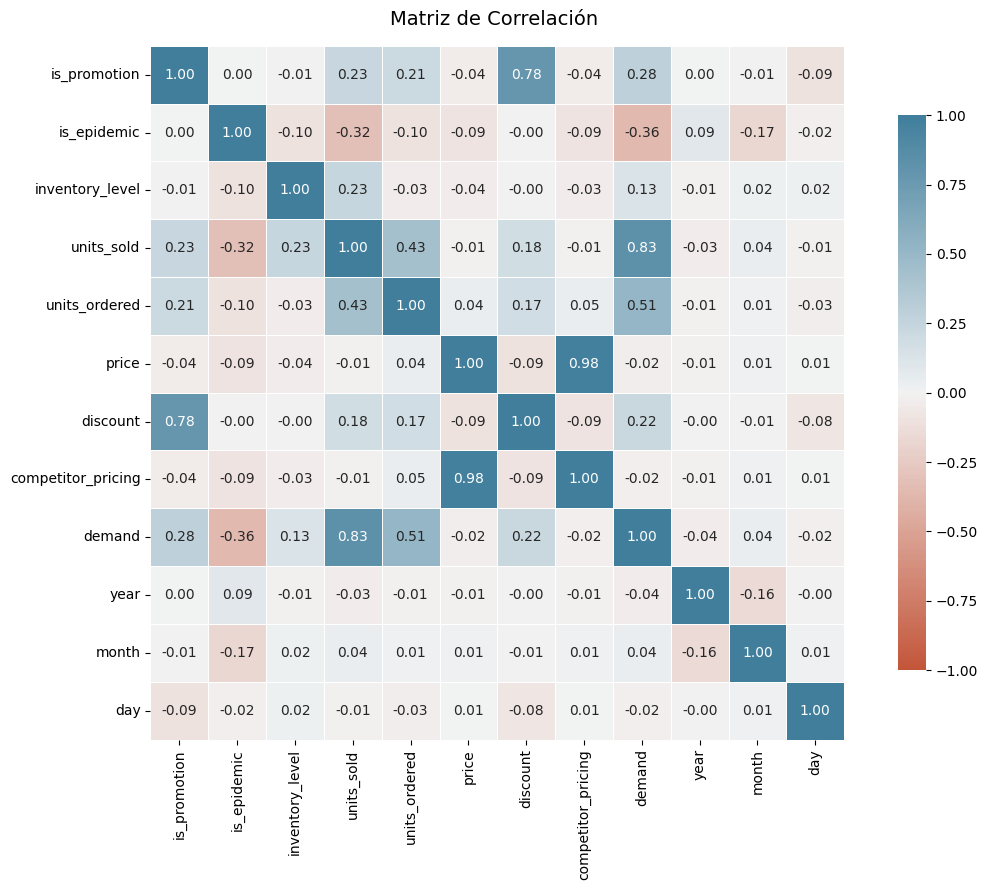

In [ ]:
# Crea una copia independiente para trabajar sin modificar el DataFrame original; no recomiendo quitar copy si luego crearás nuevas columnas.
df_corr = df.copy()
# Convierte categorías en códigos numéricos para calcular correlaciones; no lo uses si la columna no es category porque puede fallar.
df_corr['is_promotion'] = df_corr['is_promotion'].cat.codes
# Convierte categorías en códigos numéricos para calcular correlaciones; no lo uses si la columna no es category porque puede fallar.
df_corr['is_epidemic'] = df_corr['is_epidemic'].cat.codes

# Calcula la matriz de correlación entre variables numéricas; numeric_only=True evita errores con texto.
corr_matrix = df_corr.corr(numeric_only=True)

# Crea el espacio de gráficos y sus ejes; puedes cambiar figsize para hacerlos más grandes o pequeños, y la cantidad de filas/columnas si ajustas axes.
fig, ax = plt.subplots(figsize=(12, 9))
# Crea un mapa de calor de correlaciones; puedes cambiar cmap, annot o tamaño, pero no cambies corr_matrix si quieres la misma matriz.
sns.heatmap(
    # Ejecuta esta línea dentro del análisis; cambia solo valores visibles como columnas, textos o colores si entiendes dónde se usan después.
    corr_matrix,
    # Crea o actualiza la variable 'center' para usarla en pasos posteriores; puedes cambiar el valor de la derecha, pero revisa que no rompa celdas siguientes.
    center=0,
    # Crea o actualiza la variable 'vmin' para usarla en pasos posteriores; puedes cambiar el valor de la derecha, pero revisa que no rompa celdas siguientes.
    vmin=-1, vmax=1,
    # Crea o actualiza la variable 'linewidths' para usarla en pasos posteriores; puedes cambiar el valor de la derecha, pero revisa que no rompa celdas siguientes.
    linewidths=0.5,
    # Define una paleta de colores divergente para resaltar correlaciones positivas y negativas; puedes cambiar los números para variar tonos.
    cmap=sns.diverging_palette(20, 230, as_cmap=True),
    # Crea o actualiza la variable 'annot' para usarla en pasos posteriores; puedes cambiar el valor de la derecha, pero revisa que no rompa celdas siguientes.
    annot=True,
    # Crea o actualiza la variable 'fmt' para usarla en pasos posteriores; puedes cambiar el valor de la derecha, pero revisa que no rompa celdas siguientes.
    fmt='.2f',
    # Crea o actualiza la variable 'square' para usarla en pasos posteriores; puedes cambiar el valor de la derecha, pero revisa que no rompa celdas siguientes.
    square=True,
    # Crea o actualiza la variable 'cbar_kws' para usarla en pasos posteriores; puedes cambiar el valor de la derecha, pero revisa que no rompa celdas siguientes.
    cbar_kws={'shrink': 0.8},
    # Crea o actualiza la variable 'ax' para usarla en pasos posteriores; puedes cambiar el valor de la derecha, pero revisa que no rompa celdas siguientes.
    ax=ax
# Esta línea cierra una estructura anterior; no recomiendo cambiarla porque puede romper paréntesis, listas o diccionarios.
)
# Coloca el título del gráfico para explicar qué se está mostrando; puedes cambiar el texto o fontsize sin afectar los datos.
ax.set_title('Matriz de Correlación ', fontsize=14, pad=15)

plt.tight_layout()

plt.show()

## 5. Data Transformation — Producto P009 y tratamiento de outliers

En esta parte se prepara el subconjunto del producto **P0009**. Como no se está reemplazando nulos, la transformación principal consiste en identificar y retirar outliers de demanda mediante IQR.


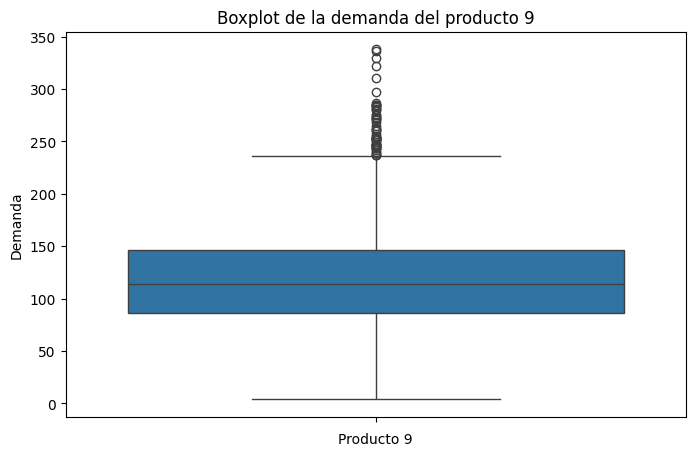

In [ ]:
#Limpiar data a solo tener P09

# Filtra la data para analizar solo el producto P0009; puedes cambiar 'P0009' por otro product_id existente.
df_producto_9 = df[df["product_id"] == "P0009"]
# Define el tamaño de una figura simple; puedes cambiar figsize, y el gráfico saldrá más ancho, alto, pequeño o grande.
plt.figure(figsize=(8, 5))

# Crea un boxplot para ver mediana, dispersión y posibles outliers; puedes cambiar x/y, data o color para analizar otra variable.
sns.boxplot(
    # Crea o actualiza la variable 'data' para usarla en pasos posteriores; puedes cambiar el valor de la derecha, pero revisa que no rompa celdas siguientes.
    data=df_producto_9,
    # Crea o actualiza la variable 'y' para usarla en pasos posteriores; puedes cambiar el valor de la derecha, pero revisa que no rompa celdas siguientes.
    y="demand"
# Esta línea cierra una estructura anterior; no recomiendo cambiarla porque puede romper paréntesis, listas o diccionarios.
)

# Coloca el título del gráfico para explicar qué se está mostrando; puedes cambiar el texto o fontsize sin afectar los datos.
plt.title("Boxplot de la demanda del producto 9")
# Define la etiqueta del eje Y; puedes cambiar el texto para explicar mejor la variable, sin afectar los cálculos.
plt.ylabel("Demanda")
# Define la etiqueta del eje X; puedes cambiar el texto para que la exposición sea más clara, sin afectar los cálculos.
plt.xlabel("Producto 9")


plt.show()

In [ ]:
# Calcula el percentil 0.25 de demand; puedes cambiar ese valor entre 0 y 1, y el corte de análisis se moverá.
Q1 = df_producto_9["demand"].quantile(0.25)
# Calcula el percentil 0.75 de demand; puedes cambiar ese valor entre 0 y 1, y el corte de análisis se moverá.
Q3 = df_producto_9["demand"].quantile(0.75)
# Calcula el rango intercuartílico restando Q1 a Q3; no recomiendo cambiar esta fórmula porque es la base del método IQR.
IQR = Q3 - Q1

# Calcula el límite inferior para detectar outliers; puedes cambiar 1.5 para ser más o menos estricto.
limite_inferior = Q1 - 1.5 * IQR
# Calcula el límite superior para detectar outliers; si subes 1.5 habrá menos outliers, si lo bajas habrá más.
limite_superior = Q3 + 1.5 * IQR

# Imprime un resultado para revisarlo en la salida; puedes cambiar el texto, pero evita cambiar variables si quieres conservar la lógica.
print("Q1:", Q1)
# Imprime un resultado para revisarlo en la salida; puedes cambiar el texto, pero evita cambiar variables si quieres conservar la lógica.
print("Q3:", Q3)
# Imprime un resultado para revisarlo en la salida; puedes cambiar el texto, pero evita cambiar variables si quieres conservar la lógica.
print("IQR:", IQR)
# Imprime un resultado para revisarlo en la salida; puedes cambiar el texto, pero evita cambiar variables si quieres conservar la lógica.
print("Límite inferior:", limite_inferior)
# Imprime un resultado para revisarlo en la salida; puedes cambiar el texto, pero evita cambiar variables si quieres conservar la lógica.
print("Límite superior:", limite_superior)

# Comentario de apoyo: esta línea ya es un comentario sobre 'Crear columna que indique si es outlier'; puedes mejorar el texto, pero no afecta los cálculos.
# Crear columna que indique si es outlier
# Crea la columna Outlier para identificar registros atípicos; cambia el nombre solo si actualizas las siguientes celdas.
df_producto_9["Outlier"] = (
    # Ejecuta esta línea dentro del análisis; cambia solo valores visibles como columnas, textos o colores si entiendes dónde se usan después.
    (df_producto_9["demand"] < limite_inferior) |
    # Ejecuta esta línea dentro del análisis; cambia solo valores visibles como columnas, textos o colores si entiendes dónde se usan después.
    (df_producto_9["demand"] > limite_superior)
# Esta línea cierra una estructura anterior; no recomiendo cambiarla porque puede romper paréntesis, listas o diccionarios.
)

# Comentario de apoyo: esta línea ya es un comentario sobre 'Ver cuántos outliers hay'; puedes mejorar el texto, pero no afecta los cálculos.
# Ver cuántos outliers hay
# Cuenta cuántas veces aparece cada valor de Outlier; puedes cambiar la columna para analizar otra categoría.
print(df_producto_9["Outlier"].value_counts())

Q1: 86.0
Q3: 146.0
IQR: 60.0
Límite inferior: -4.0
Límite superior: 236.0
Outlier
False    3742
True       58
Name: count, dtype: int64


In [ ]:
# Crear un nuevo dataframe sin outliers

# Crea la columna Outlier para identificar registros atípicos; cambia el nombre solo si actualizas las siguientes celdas.
df_producto_9_sin_outliers = df_producto_9[df_producto_9["Outlier"] == False].copy()

# Comentario de apoyo: esta línea ya es un comentario sobre 'Verificar cantidad de registros antes y después'; puedes mejorar el texto, pero no afecta los cálculos.
# Verificar cantidad de registros antes y después
# Imprime un resultado para revisarlo en la salida; puedes cambiar el texto, pero evita cambiar variables si quieres conservar la lógica.
print("Registros originales:", len(df_producto_9))
# Imprime un resultado para revisarlo en la salida; puedes cambiar el texto, pero evita cambiar variables si quieres conservar la lógica.
print("Registros sin outliers:", len(df_producto_9_sin_outliers))
# Imprime un resultado para revisarlo en la salida; puedes cambiar el texto, pero evita cambiar variables si quieres conservar la lógica.
print("Registros eliminados:", len(df_producto_9) - len(df_producto_9_sin_outliers))

Registros originales: 3800
Registros sin outliers: 3742
Registros eliminados: 58


## 6. Insights — análisis del Producto P009

Esta sección queda centrada solo en el análisis del producto **P0009** después del tratamiento de outliers.


In [ ]:
# Calcula estadísticas descriptivas como media, mínimos, máximos y cuartiles; puedes cambiar la columna para resumir otra variable.
print(df_producto_9_sin_outliers["demand"].describe())

count    3742.000000
mean      116.230625
std        42.523890
min         4.000000
25%        86.000000
50%       113.000000
75%       144.000000
max       236.000000
Name: demand, dtype: float64


In [ ]:
# Calcula la moda, es decir, el valor más frecuente; puedes cambiar el DataFrame o columna para buscar otra moda.
df_producto_9_sin_outliers["demand"].mode()

0    101
Name: demand, dtype: int64

In [ ]:
# Calcula la mediana, un valor central robusto ante outliers; puedes cambiar la columna si quieres otra variable.
df_producto_9_sin_outliers["demand"].median()

np.float64(113.0)

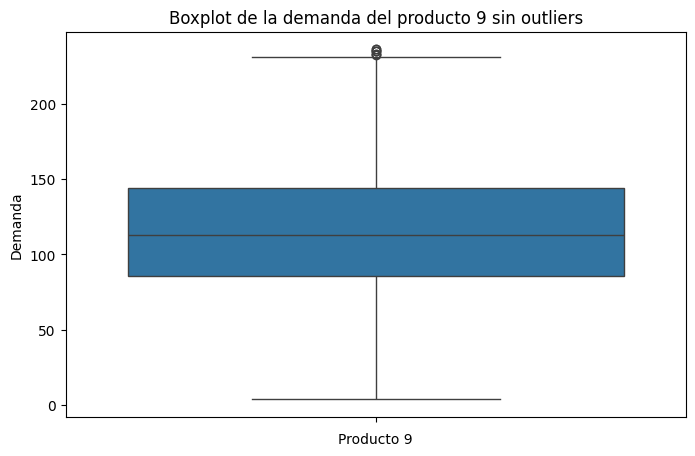

In [ ]:
# Define el tamaño de una figura simple; puedes cambiar figsize, y el gráfico saldrá más ancho, alto, pequeño o grande.
plt.figure(figsize=(8, 5))

# Crea un boxplot para ver mediana, dispersión y posibles outliers; puedes cambiar x/y, data o color para analizar otra variable.
sns.boxplot(
    # Crea o actualiza la variable 'data' para usarla en pasos posteriores; puedes cambiar el valor de la derecha, pero revisa que no rompa celdas siguientes.
    data=df_producto_9_sin_outliers,
    # Crea o actualiza la variable 'y' para usarla en pasos posteriores; puedes cambiar el valor de la derecha, pero revisa que no rompa celdas siguientes.
    y="demand"
# Esta línea cierra una estructura anterior; no recomiendo cambiarla porque puede romper paréntesis, listas o diccionarios.
)

# Coloca el título del gráfico para explicar qué se está mostrando; puedes cambiar el texto o fontsize sin afectar los datos.
plt.title("Boxplot de la demanda del producto 9 sin outliers")
# Define la etiqueta del eje Y; puedes cambiar el texto para explicar mejor la variable, sin afectar los cálculos.
plt.ylabel("Demanda")
# Define la etiqueta del eje X; puedes cambiar el texto para que la exposición sea más clara, sin afectar los cálculos.
plt.xlabel("Producto 9")

plt.show()

# Resumen de la celda:
# se calculan percentiles, límites o outliers para entender valores extremos.
# Si el profesor me pide cambiar algo, lo más fácil sería modificar:
# percentiles, 1.5 del IQR o threshold=3.
# Ejemplo de cambio rápido:
# limite_superior = Q3 + 2.0 * IQR

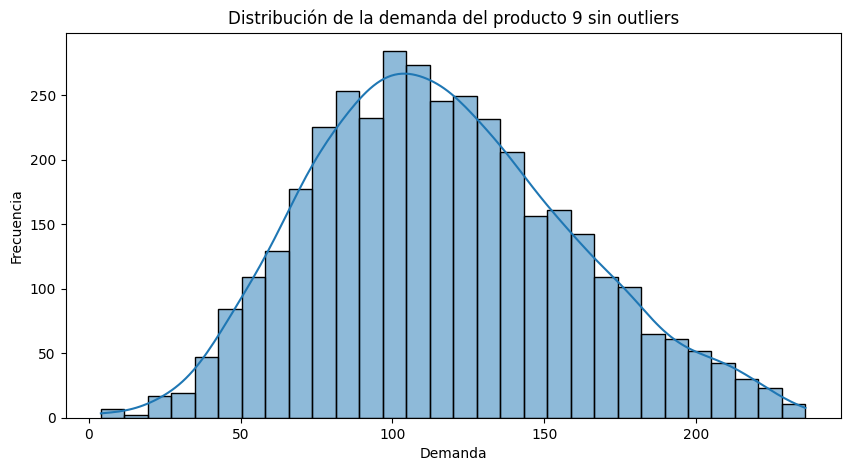

In [ ]:
# Define el tamaño de una figura simple; puedes cambiar figsize, y el gráfico saldrá más ancho, alto, pequeño o grande.
plt.figure(figsize=(10, 5))

# Crea un histograma para ver distribución de una variable; puedes cambiar x, bins o color, y cambiará la columna, detalle o color del gráfico.
sns.histplot(
    # Crea o actualiza la variable 'data' para usarla en pasos posteriores; puedes cambiar el valor de la derecha, pero revisa que no rompa celdas siguientes.
    data=df_producto_9_sin_outliers,
    # Crea o actualiza la variable 'x' para usarla en pasos posteriores; puedes cambiar el valor de la derecha, pero revisa que no rompa celdas siguientes.
    x="demand",
    # Crea o actualiza la variable 'bins' para usarla en pasos posteriores; puedes cambiar el valor de la derecha, pero revisa que no rompa celdas siguientes.
    bins=30,
    # Crea o actualiza la variable 'kde' para usarla en pasos posteriores; puedes cambiar el valor de la derecha, pero revisa que no rompa celdas siguientes.
    kde=True
# Esta línea cierra una estructura anterior; no recomiendo cambiarla porque puede romper paréntesis, listas o diccionarios.
)

# Coloca el título del gráfico para explicar qué se está mostrando; puedes cambiar el texto o fontsize sin afectar los datos.
plt.title("Distribución de la demanda del producto 9 sin outliers")
# Define la etiqueta del eje X; puedes cambiar el texto para que la exposición sea más clara, sin afectar los cálculos.
plt.xlabel("Demanda")
# Define la etiqueta del eje Y; puedes cambiar el texto para explicar mejor la variable, sin afectar los cálculos.
plt.ylabel("Frecuencia")

plt.show()

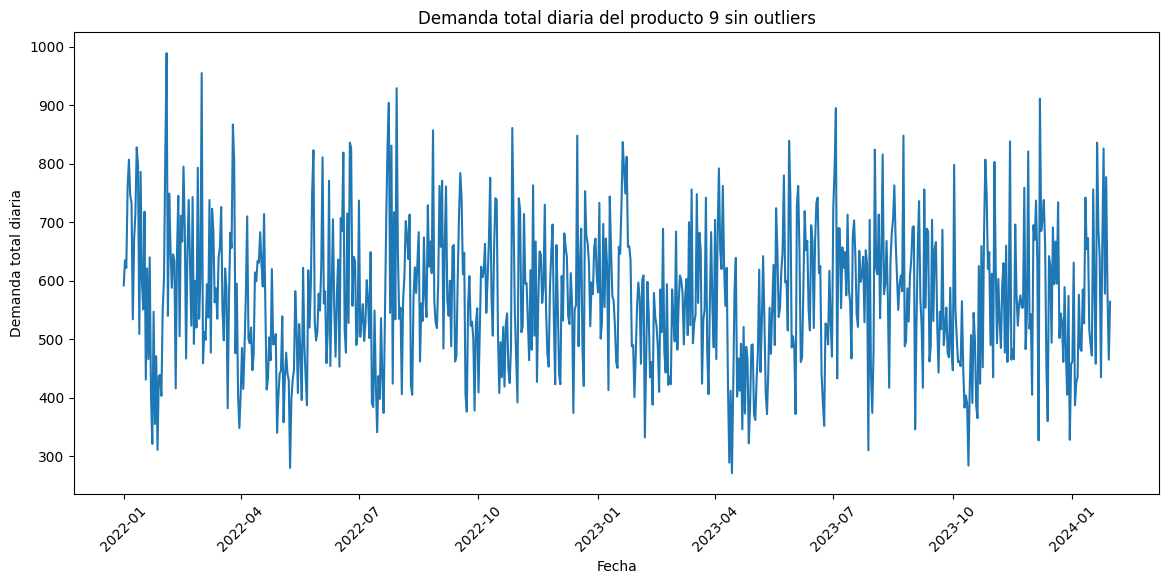

In [ ]:
# Convierte una columna de fecha a formato datetime para poder extraer año, mes o graficar en el tiempo; cambia el nombre de columna solo si existe.
df_producto_9_sin_outliers["date"] = pd.to_datetime(df_producto_9_sin_outliers["date"])

# Agrupa datos y devuelve una tabla normal con índices reiniciados; puedes cambiar la columna de agrupación o la métrica si existe.
demanda_diaria = df_producto_9_sin_outliers.groupby("date")["demand"].sum().reset_index()

# Define el tamaño de una figura simple; puedes cambiar figsize, y el gráfico saldrá más ancho, alto, pequeño o grande.
plt.figure(figsize=(14, 6))

# Ejecuta esta línea dentro del análisis; cambia solo valores visibles como columnas, textos o colores si entiendes dónde se usan después.
sns.lineplot(
    # Crea o actualiza la variable 'data' para usarla en pasos posteriores; puedes cambiar el valor de la derecha, pero revisa que no rompa celdas siguientes.
    data=demanda_diaria,
    # Crea o actualiza la variable 'x' para usarla en pasos posteriores; puedes cambiar el valor de la derecha, pero revisa que no rompa celdas siguientes.
    x="date",
    # Crea o actualiza la variable 'y' para usarla en pasos posteriores; puedes cambiar el valor de la derecha, pero revisa que no rompa celdas siguientes.
    y="demand"
# Esta línea cierra una estructura anterior; no recomiendo cambiarla porque puede romper paréntesis, listas o diccionarios.
)

# Coloca el título del gráfico para explicar qué se está mostrando; puedes cambiar el texto o fontsize sin afectar los datos.
plt.title("Demanda total diaria del producto 9 sin outliers")
# Define la etiqueta del eje X; puedes cambiar el texto para que la exposición sea más clara, sin afectar los cálculos.
plt.xlabel("Fecha")
# Define la etiqueta del eje Y; puedes cambiar el texto para explicar mejor la variable, sin afectar los cálculos.
plt.ylabel("Demanda total diaria")
# Ajusta las etiquetas del eje X; puedes cambiar rotation para que las fechas se lean mejor.
plt.xticks(rotation=45)

plt.show()

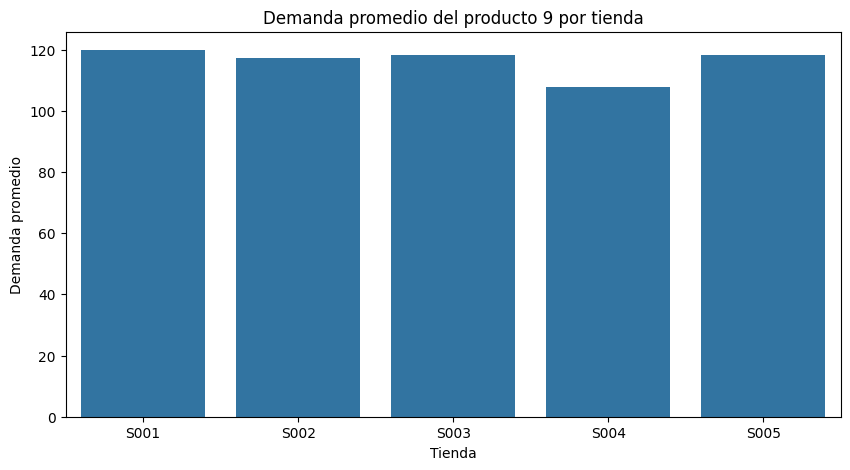

In [ ]:
# Agrupa datos y devuelve una tabla normal con índices reiniciados; puedes cambiar la columna de agrupación o la métrica si existe.
demanda_tienda = df_producto_9_sin_outliers.groupby("store_id")["demand"].mean().reset_index()

# Define el tamaño de una figura simple; puedes cambiar figsize, y el gráfico saldrá más ancho, alto, pequeño o grande.
plt.figure(figsize=(10, 5))

# Crea un gráfico de barras para comparar valores por producto, tienda o categoría; puedes cambiar x/y, palette o ax para otra comparación.
sns.barplot(
    # Crea o actualiza la variable 'data' para usarla en pasos posteriores; puedes cambiar el valor de la derecha, pero revisa que no rompa celdas siguientes.
    data=demanda_tienda,
    # Crea o actualiza la variable 'x' para usarla en pasos posteriores; puedes cambiar el valor de la derecha, pero revisa que no rompa celdas siguientes.
    x="store_id",
    # Crea o actualiza la variable 'y' para usarla en pasos posteriores; puedes cambiar el valor de la derecha, pero revisa que no rompa celdas siguientes.
    y="demand"
# Esta línea cierra una estructura anterior; no recomiendo cambiarla porque puede romper paréntesis, listas o diccionarios.
)

# Coloca el título del gráfico para explicar qué se está mostrando; puedes cambiar el texto o fontsize sin afectar los datos.
plt.title("Demanda promedio del producto 9 por tienda")
# Define la etiqueta del eje X; puedes cambiar el texto para que la exposición sea más clara, sin afectar los cálculos.
plt.xlabel("Tienda")
# Define la etiqueta del eje Y; puedes cambiar el texto para explicar mejor la variable, sin afectar los cálculos.
plt.ylabel("Demanda promedio")

plt.show()